<a href="https://colab.research.google.com/github/ekomissarov/sutva-tsm/blob/main/tsm_events_aggregation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Документация к SQL-пайплайну подготовки panel-таблицы для switchback-эксперимента

## 1. Назначение

SQL-пайплайн формирует агрегированную panel-таблицу для анализа switchback A/B-теста в двустороннем marketplace, например ride-hailing сервисе.

Единица наблюдения в итоговой таблице:

\[
(region\_id,\ interval\_start)
\]

то есть один регион в одном экспериментальном временном окне.

В текущей конфигурации длина окна составляет 30 минут:

```sql
interval '30 minutes'
```

Для каждого такого окна рассчитываются:

- характеристики спроса;
- результаты матчинга;
- завершённые и отменённые поездки;
- GMV;
- показатели supply;
- среднее количество одновременно доступных водителей;
- нагрузка на доступный supply;
- treatment assignment;
- treatment предыдущего временного окна.

Все ride-level outcomes относятся к тому экспериментальному окну, в котором была создана исходная заявка `ride_requested`.

---

# 2. Входные таблицы

## 2.1. `ride_requested`

Таблица содержит события создания заявки на поездку.

Каждая строка соответствует событию создания одной поездки.

Пример:

| event_time | user_id | ride_id | region_id |
|---|---|---|---|
| 08:01:15 | U123 | R001 | South |
| 08:04:10 | U918 | R002 | South |

### Поля

| Поле | Описание |
|---|---|
| `event_time` | Время создания заявки |
| `user_id` | Идентификатор пользователя |
| `ride_id` | Идентификатор поездки |
| `region_id` | Регион, в котором была создана заявка |

`ride_id` используется как основной идентификатор для связывания заявки с последующими событиями поездки.

Перед дальнейшей обработкой таблица дедуплицируется по `ride_id`. Если существует несколько записей одного `ride_id`, используется самая ранняя:

```sql
row_number() over (
    partition by ride_id
    order by event_time asc
)
```

Это предотвращает размножение строк при последующих `JOIN`.

---

## 2.2. `match_created`

Таблица содержит события назначения водителя на поездку.

Пример:

| event_time | ride_id | driver_id |
|---|---|---|
| 08:02:14 | R001 | D041 |

### Поля

| Поле | Описание |
|---|---|
| `event_time` | Время создания матча |
| `ride_id` | Идентификатор поездки |
| `driver_id` | Идентификатор назначенного водителя |

Для каждой поездки используется **первый зарегистрированный match**.

Поэтому метрика времени ожидания имеет семантику:

\[
wait\_time =
first\_match\_time - request\_time
\]

Это время от создания заявки до первого назначения водителя.

Если в продукте возможны rematch-сценарии, последующие `match_created` для той же поездки в текущей версии пайплайна не используются.

---

## 2.3. `ride_completed`

Таблица содержит события завершения поездок.

Пример:

| event_time | ride_id | price |
|---|---|---:|
| 08:26:50 | R001 | 435 |

### Поля

| Поле | Описание |
|---|---|
| `event_time` | Время завершения поездки |
| `ride_id` | Идентификатор поездки |
| `price` | Стоимость завершённой поездки |

Для каждого `ride_id` используется первая зарегистрированная completion-запись.

Это защищает расчёт GMV от технических дублей, например при at-least-once доставке событий.

---

## 2.4. `ride_cancelled`

Таблица содержит события отмены поездок.

Пример:

| event_time | ride_id | reason |
|---|---|---|
| 08:05:44 | R002 | driver_timeout |

### Поля

| Поле | Описание |
|---|---|
| `event_time` | Время отмены |
| `ride_id` | Идентификатор поездки |
| `reason` | Причина отмены |

Для каждой поездки используется первая зарегистрированная cancellation-запись.

Отдельно рассчитывается количество отмен по причине:

```text
driver_timeout
```

---

## 2.5. `driver_online`

Несмотря на название, таблица содержит не только факт выхода водителя online, а **события изменения состояния водителя**.

Фактическая семантика таблицы ближе к `driver_status_changed`.

Пример:

| event_time | driver_id | region_id | status |
|---|---|---|---|
| 08:00:00 | D041 | South | available |
| 08:05:00 | D041 | South | busy |
| 08:27:00 | D041 | South | available |
| 08:45:00 | D041 | South | offline |

### Поля

| Поле | Описание |
|---|---|
| `event_time` | Время перехода в новое состояние |
| `driver_id` | Идентификатор водителя |
| `region_id` | Регион нахождения водителя |
| `status` | Новое состояние водителя |

Допустимые значения:

```text
available
busy
offline
```

### Семантика статусов

`available` означает, что водитель находится online и может принять новую заявку.

`busy` означает, что водитель находится online, но занят и в данный момент недоступен для нового матчинга.

`offline` означает, что водитель не является частью текущего supply.

Последовательность событий:

```text
08:00 available
08:05 busy
08:27 available
08:45 offline
```

преобразуется в интервалы состояния:

```text
[08:00, 08:05) available
[08:05, 08:27) busy
[08:27, 08:45) available
```

`offline`-сегменты в supply-агрегации не используются.

---

## 2.6. `switchback_assignments`

Таблица содержит экспериментальное назначение для каждого региона и временного окна.

Пример:

| interval_start | region_id | treatment |
|---|---|---:|
| 08:00 | South | 1 |
| 08:30 | South | 1 |
| 09:00 | South | 0 |
| 09:30 | South | 0 |

### Поля

| Поле | Описание |
|---|---|
| `interval_start` | Начало switchback-окна |
| `region_id` | Регион |
| `treatment` | Экспериментальное назначение |

В текущей схеме:

```text
treatment = 1 → treatment
treatment = 0 → control
```

Таблица должна содержать полную экспериментальную сетку `(region_id, interval_start)`.

Она одновременно используется как:

- источник treatment assignment;
- источник полного набора экспериментальных окон;
- основа для предотвращения пропусков при вычислении `LAG()`.

---

# 3. Параметры временного биннинга

В начале запроса задаются:

```sql
interval '30 minutes' as interval_len
```

и:

```sql
timestamp '2000-01-01 00:00:00' as bin_origin
```

`interval_len` задаёт продолжительность switchback-окна.

`bin_origin` задаёт общую точку отсчёта для функции:

```sql
date_bin(...)

--реализован напрямую
p.bin_origin
        + floor(
            date_diff('second', p.bin_origin, r.event_time)
            / extract(epoch from p.interval_len)
          ) * p.interval_len as interval_start
```

Критически важно, чтобы тот же `bin_origin` использовался при построении `switchback_assignments`.

Иначе одинаковое событие может попасть в один временной бин в event pipeline и в другой — в assignment pipeline, после чего `JOIN` по `interval_start` станет некорректным.

---

# 4. Атрибуция поездок к switchback-окнам

Каждая заявка получает:

```sql
interval_start
```

на основании времени `ride_requested`.

Например:

```text
request = 08:25
```

при 30-минутных окнах относится к:

```text
interval_start = 08:00
```

Все дальнейшие outcomes этой поездки наследуют **тот же** `interval_start`.

Например:

```text
request     08:25
match       08:28
completion  08:47
```

все показатели поездки относятся к:

```text
08:00
```

Несмотря на то, что `completion` произошёл уже в следующем физическом временном окне.

Таким образом treatment определяется состоянием эксперимента **в момент создания заявки**:

\[
T_i =
T(region_i,\ request\_time_i)
\]

Это относится к таким метрикам, как:

- `matched`;
- `completed`;
- `gmv`;
- `cancelled`;
- `avg_wait_time_matched`.

---

# 5. Формирование driver-state сегментов

Исходные driver events сначала очищаются от полностью идентичных дублей:

```sql
select distinct
    driver_id,
    region_id,
    event_time,
    status
```

После этого удаляются последовательные повторения одинакового состояния.

Например:

```text
08:00 available
08:01 available
08:02 available
08:07 busy
```

преобразуются в:

```text
08:00 available
08:07 busy
```

Если водитель меняет регион, это также считается началом нового состояния, даже если `status` формально не изменился.

Например:

```text
08:00 South available
08:20 North available
```

создаёт два сегмента:

```text
South [08:00, 08:20) available
North [08:20, ...)
```

Конец каждого сегмента определяется следующим driver event через:

```sql
lead(event_time)
```

---

# 6. Расчёт supply

Для каждого экспериментального окна:

\[
[t,\ t+L)
\]

driver-state сегмент включается в расчёт, если существует непустое пересечение:

\[
state\_start < t+L
\]

и:

\[
state\_end > t
\]

Используются half-open intervals:

\[
[start,\ end)
\]

Это означает, например, что событие ровно в `08:30:00` уже относится к окну:

```text
[08:30, 09:00)
```

а не к:

```text
[08:00, 08:30)
```

Для каждого пересечения рассчитывается фактическое число минут, проведённых водителем в состоянии `available` или `busy`.

---

# 7. Выходная таблица

Финальный результат содержит **одну строку на каждый `(region_id, interval_start)`** из `switchback_assignments`.

Например:

| region_id | interval_start | treatment | requests | matched | completed | ... |
|---|---|---:|---:|---:|---:|---|
| South | 08:00 | 1 | 120 | 108 | 94 | ... |
| South | 08:30 | 1 | 134 | 119 | 101 | ... |
| South | 09:00 | 0 | 127 | 109 | 96 | ... |

Даже если внутри экспериментального окна нет ни одной заявки или поездки, строка сохраняется благодаря полной сетке `switchback_assignments`.

---

# 8. Описание выходных полей

## `region_id`

Регион, соответствующий данной строке panel-таблицы.

Единица экспериментальной рандомизации включает комбинацию региона и временного окна.

---

## `interval_start`

Начало switchback-окна.

Например:

```text
08:00
08:30
09:00
09:30
```

При `interval_len = 30 minutes` строка `08:00` соответствует интервалу:

\[
[08{:}00,\ 08{:}30)
\]

---

## `treatment`

Treatment assignment данного региона в данном временном окне.

```text
1 = treatment
0 = control
```

---

## `requests`

Количество уникальных поездок, созданных в данном регионе внутри данного окна:

\[
Requests_{r,t}
\]

Считается по `ride_requested`.

---

## `matched`

Количество заявок из данного окна, которые получили хотя бы один match.

Поскольку используется первый `match_created`, каждая поездка учитывается максимум один раз.

---

## `completed`

Количество заявок из данного request-окна, которые в дальнейшем завершились успешно.

Важно: поездка учитывается в окне **создания заявки**, а не в окне фактического завершения.

---

## `gmv`

Сумма `price` всех завершённых поездок, заявки на которые были созданы в данном окне:

\[
GMV_{r,t}
=
\sum_i price_i
\]

---

## `cancelled`

Количество заявок из данного окна, для которых была зарегистрирована отмена.

---

## `cancelled_driver_timeout`

Количество отмен, для которых:

```text
reason = 'driver_timeout'
```

Метрика может использоваться как дополнительный индикатор проблем со стороны supply или matching process.

---

# 9. Supply-поля

## `drivers_available`

Количество уникальных водителей, которые **хотя бы часть данного окна** находились в состоянии:

```text
available
```

Например, если:

```text
D1 available 08:00–08:05
D2 available 08:25–08:30
```

то:

```text
drivers_available = 2
```

Даже несмотря на то, что эти два водителя никогда не были `available` одновременно.

Поэтому поле **не является concurrent supply**.

---

## `drivers_busy`

Количество уникальных водителей, которые хотя бы часть окна находились в состоянии:

```text
busy
```

---

## `drivers_online_total`

Количество уникальных водителей, которые хотя бы часть окна находились либо:

```text
available
```

либо:

```text
busy
```

Один водитель учитывается максимум один раз, даже если внутри одного окна переходил между `available` и `busy`.

---

## `available_driver_minutes`

Суммарное количество минут, проведённых всеми водителями в состоянии `available` внутри данного окна.

Формально:

\[
AvailableDriverMinutes_{r,t}
=
\sum_d AvailableMinutes_{d,r,t}
\]

Например:

```text
D1: 30 available minutes
D2: 20 available minutes
D3: 10 available minutes
```

даёт:

\[
AvailableDriverMinutes = 60
\]

---

## `busy_driver_minutes`

Суммарное число минут, проведённых водителями в состоянии `busy`.

\[
BusyDriverMinutes_{r,t}
=
\sum_d BusyMinutes_{d,r,t}
\]

---

## `online_driver_minutes`

Суммарное online-время supply:

\[
OnlineDriverMinutes
=
AvailableDriverMinutes
+
BusyDriverMinutes
\]

В SQL:

```sql
available_driver_minutes
+
busy_driver_minutes
```

---

## `avg_available_drivers`

Среднее число одновременно доступных водителей в течение окна.

Рассчитывается как:

\[
AvgAvailableDrivers
=
\frac{AvailableDriverMinutes}
{WindowLengthMinutes}
\]

Для 30-минутного окна:

\[
AvgAvailableDrivers
=
\frac{AvailableDriverMinutes}{30}
\]

Например:

\[
\frac{60}{30}=2
\]

означает, что в среднем на протяжении данного 30-минутного окна одновременно были доступны два водителя.

Это одна из основных характеристик эффективного supply.

---

## `avg_online_drivers`

Среднее количество одновременно online-водителей независимо от их занятости:

\[
AvgOnlineDrivers
=
\frac{
AvailableDriverMinutes + BusyDriverMinutes
}{
WindowLengthMinutes
}
\]

Включает как `available`, так и `busy` supply.

---

# 10. Marketplace-метрики

## `load_available`

Характеризует нагрузку спроса на доступный supply:

\[
LoadAvailable
=
\frac{Requests}
{AvgAvailableDrivers}
\]

Например:

```text
requests = 120
avg_available_drivers = 20
```

тогда:

\[
LoadAvailable=6
\]

То есть на одну среднюю одновременно доступную единицу supply пришлось 6 заявок за экспериментальное окно.

Если:

```text
avg_available_drivers = 0
```

метрика возвращается как `NULL`.

---

## `match_rate`

Доля заявок, которые получили match:

\[
MatchRate
=
\frac{Matched}{Requests}
\]

Если в окне нет requests, возвращается `NULL`.

---

## `avg_wait_time_matched`

Среднее время от создания заявки до первого match:

\[
AvgWaitTimeMatched
=
E[
MatchTime - RequestTime
\mid Matched
]
\]

Измеряется в минутах.

Это **условная метрика только среди успешно matched заявок**.

Поэтому её необходимо интерпретировать совместно с `match_rate`.

Например treatment теоретически может привести к тому, что самые проблемные заявки вообще перестанут матчиться. Тогда `match_rate` снизится, но `avg_wait_time_matched` среди оставшихся заявок может уменьшиться.

---

# 11. `treat_lag1`

Поле:

```sql
lag(treatment) over (
    partition by region_id
    order by interval_start
)
```

содержит treatment assignment **предыдущего switchback-окна того же региона**.

Например:

| interval_start | treatment | treat_lag1 |
|---|---:|---:|
| 08:00 | 1 | NULL |
| 08:30 | 1 | 1 |
| 09:00 | 0 | 1 |
| 09:30 | 0 | 0 |

`treat_lag1` не относится к конкретной поездке.

Он означает:

> какой experimental condition действовал в данном регионе в непосредственно предыдущем switchback-окне.

Поле может использоваться для анализа carryover / lagged treatment effects.

---

# 12. Основные группы выходных метрик

Итоговую panel-таблицу удобно интерпретировать как комбинацию четырёх групп данных.

### Experiment assignment

```text
region_id
interval_start
treatment
treat_lag1
```

### Demand и ride outcomes

```text
requests
matched
completed
gmv
cancelled
cancelled_driver_timeout
```

### Supply

```text
drivers_available
drivers_busy
drivers_online_total
available_driver_minutes
busy_driver_minutes
online_driver_minutes
avg_available_drivers
avg_online_drivers
```

### Marketplace balance / matching

```text
load_available
match_rate
avg_wait_time_matched
```

Таким образом итоговая строка описывает одновременно experimental assignment, спрос, supply и результаты функционирования marketplace в конкретном регионе и конкретном switchback-окне.

# Доп наблюдения
* Нет проверок на «отрицательное» время.
wait_minutes считается как match.event_time - request.event_time без проверки, что матч не мог произойти раньше заявки. Аналогично для completion/cancellation. Если апстрим когда-нибудь пришлёт данные с рассинхроном часов, метрика тихо получит отрицательные значения, которые попадут в avg_wait_time_matched. Не критично для текущего пайплайна, но стоит хотя бы залогировать/отфильтровать такие случаи отдельно.

* analysis_bounds считается глобально, а не по регионам.
driver_segments обрезается по единым analysis_start/analysis_end для всех регионов сразу (взятым из min/max по всей switchback_assignments). Если когда-нибудь у разных регионов будут разные по длине экспериментальные окна (например, регион добавили в эксперимент позже), водительские сегменты в «раннем» регионе будут неверно обрезаны по границам «позднего». В текущих тестовых данных North и South синхронны, поэтому баг не проявляется — но это скрытое предположение, которое стоит явно задокументировать или сделать analysis_bounds per-region.

* load_available дублирует вычисление avg_available_drivers вместо переиспользования.
В CASE-выражении для load_available заново делится sp.available_driver_minutes на длину окна, хотя чуть выше уже вычислен avg_available_drivers с той же формулой. Не баг, но лишний источник рассинхрона, если формулу поменяют в одном месте и забудут в другом.

* Нет проверки на нарушение взаимоисключаемости completed/cancelled.
Если апстрим когда-нибудь пришлёт для одной поездки и ride_completed, и ride_cancelled (гонка/баг источника), пайплайн молча посчитает её и там, и там — requests не превысится, но completed + cancelled может быть больше matched. Стоит либо явно задокументировать допущение «эти события взаимоисключающие по построению», либо добавить sanity-check.

* avg_wait_time_matched может остаться NaN после uplift на `matched`.
_recompute_derived проставляет NaN в avg_wait_time_matched только когда matched == 0, но не восстанавливает значение, если matched стал > 0 в результате apply_uplift(metric="matched", ...) на слоте, где matched исходно был 0 (а avg_wait_time_matched уже был NaN — восстановить его неоткуда, реальные wait-time наблюдения для этого слота не генерировались). На практике при base_match_rate≈0.9 такие слоты почти не встречаются, поэтому это не влияет на текущие AA/AB симуляции, но стоит иметь в виду при uplift на "matched" с низким base_match_rate.

* run_aa_simulations/estimate_reject_prob были продублированы в двух ячейках (генератор и AA simulations) — второе определение тихо перекрывало первое. Дубликат удалён, осталась одна версия в разделе AA simulations.


# генерация тестовых данных для event таблиц

In [ ]:
import pandas as pd
import numpy as np

# Magics
from helpers import (
    load_sql_magic,
    load_viz_magic
)
load_sql_magic()          # %%sql   — query DataFrames via duckdb (no extra installs)
load_viz_magic()          # %%viz   — open a DataFrame in PyGWalker (drag-and-drop charts)

# ============================================================
# 1. SWITCHBACK ASSIGNMENTS
# ============================================================

intervals = pd.date_range(
    start="2026-08-01 08:00:00",
    end="2026-08-01 11:30:00",
    freq="30min"
)

regions = ["South", "North"]

assignments = []

# South:
# T T C C T T C C
south_treatment = [1, 1, 0, 0, 1, 1, 0, 0]

# North:
# C C T T C C T T
north_treatment = [0, 0, 1, 1, 0, 0, 1, 1]

for region, treatment_pattern in [
    ("South", south_treatment),
    ("North", north_treatment),
]:
    for interval_start, treatment in zip(intervals, treatment_pattern):
        assignments.append(
            {
                "region_id": region,
                "interval_start": interval_start,
                "treatment": treatment,
            }
        )

switchback_assignments = pd.DataFrame(assignments)


# ============================================================
# 2. RIDE REQUESTED
# ============================================================

ride_requested = pd.DataFrame(
    [
        # ----------------------------------------------------
        # SOUTH
        # ----------------------------------------------------
        {
            "event_time": "2026-08-01 08:01:15",
            "user_id": "U001",
            "ride_id": "R001",
            "region_id": "South",
        },
        {
            "event_time": "2026-08-01 08:07:00",
            "user_id": "U002",
            "ride_id": "R002",
            "region_id": "South",
        },
        {
            "event_time": "2026-08-01 08:25:00",
            "user_id": "U003",
            "ride_id": "R003",
            "region_id": "South",
        },

        # событие ровно на границе бина
        {
            "event_time": "2026-08-01 08:30:00",
            "user_id": "U011",
            "ride_id": "R011",
            "region_id": "South",
        },

        # технический дубль R003
        {
            "event_time": "2026-08-01 08:25:02",
            "user_id": "U003",
            "ride_id": "R003",
            "region_id": "South",
        },

        {
            "event_time": "2026-08-01 08:32:00",
            "user_id": "U004",
            "ride_id": "R004",
            "region_id": "South",
        },
        {
            "event_time": "2026-08-01 08:48:00",
            "user_id": "U005",
            "ride_id": "R005",
            "region_id": "South",
        },
        {
            "event_time": "2026-08-01 09:04:00",
            "user_id": "U006",
            "ride_id": "R006",
            "region_id": "South",
        },
        {
            "event_time": "2026-08-01 09:22:00",
            "user_id": "U007",
            "ride_id": "R007",
            "region_id": "South",
        },
        {
            "event_time": "2026-08-01 09:44:00",
            "user_id": "U008",
            "ride_id": "R008",
            "region_id": "South",
        },
        {
            "event_time": "2026-08-01 10:03:00",
            "user_id": "U009",
            "ride_id": "R009",
            "region_id": "South",
        },
        {
            "event_time": "2026-08-01 10:41:00",
            "user_id": "U010",
            "ride_id": "R010",
            "region_id": "South",
        },

        # ----------------------------------------------------
        # NORTH
        # ----------------------------------------------------
        {
            "event_time": "2026-08-01 08:03:00",
            "user_id": "U101",
            "ride_id": "R101",
            "region_id": "North",
        },
        {
            "event_time": "2026-08-01 08:17:00",
            "user_id": "U102",
            "ride_id": "R102",
            "region_id": "North",
        },
        {
            "event_time": "2026-08-01 08:39:00",
            "user_id": "U103",
            "ride_id": "R103",
            "region_id": "North",
        },
        {
            "event_time": "2026-08-01 09:10:00",
            "user_id": "U104",
            "ride_id": "R104",
            "region_id": "North",
        },
        {
            "event_time": "2026-08-01 09:37:00",
            "user_id": "U105",
            "ride_id": "R105",
            "region_id": "North",
        },
        {
            "event_time": "2026-08-01 10:12:00",
            "user_id": "U106",
            "ride_id": "R106",
            "region_id": "North",
        },
        {
            "event_time": "2026-08-01 11:02:00",
            "user_id": "U107",
            "ride_id": "R107",
            "region_id": "North",
        },
    ]
)

ride_requested["event_time"] = pd.to_datetime(
    ride_requested["event_time"]
)


# ============================================================
# 3. MATCH CREATED
# ============================================================

match_created = pd.DataFrame(
    [
        # ----------------------------------------------------
        # SOUTH
        # ----------------------------------------------------
        {
            "event_time": "2026-08-01 08:02:14",
            "ride_id": "R001",
            "driver_id": "D001",
        },

        {
            "event_time": "2026-08-01 08:09:00",
            "ride_id": "R002",
            "driver_id": "D002",
        },

        {
            "event_time": "2026-08-01 08:28:00",
            "ride_id": "R003",
            "driver_id": "D003",
        },

        # rematch:
        # SQL должен взять первый match R003
        {
            "event_time": "2026-08-01 08:31:00",
            "ride_id": "R003",
            "driver_id": "D004",
        },

        {
            "event_time": "2026-08-01 08:36:00",
            "ride_id": "R004",
            "driver_id": "D001",
        },

        # R005 специально НЕ имеет match

        {
            "event_time": "2026-08-01 09:08:00",
            "ride_id": "R006",
            "driver_id": "D002",
        },

        {
            "event_time": "2026-08-01 09:29:00",
            "ride_id": "R007",
            "driver_id": "D003",
        },

        {
            "event_time": "2026-08-01 09:47:00",
            "ride_id": "R008",
            "driver_id": "D001",
        },

        {
            "event_time": "2026-08-01 10:05:00",
            "ride_id": "R009",
            "driver_id": "D002",
        },

        # R010 без match

        # ----------------------------------------------------
        # NORTH
        # ----------------------------------------------------
        {
            "event_time": "2026-08-01 08:05:00",
            "ride_id": "R101",
            "driver_id": "D101",
        },
        {
            "event_time": "2026-08-01 08:20:00",
            "ride_id": "R102",
            "driver_id": "D102",
        },
        {
            "event_time": "2026-08-01 08:42:00",
            "ride_id": "R103",
            "driver_id": "D101",
        },
        {
            "event_time": "2026-08-01 09:14:00",
            "ride_id": "R104",
            "driver_id": "D103",
        },

        # R105 без match

        {
            "event_time": "2026-08-01 10:16:00",
            "ride_id": "R106",
            "driver_id": "D102",
        },
        {
            "event_time": "2026-08-01 11:08:00",
            "ride_id": "R107",
            "driver_id": "D103",
        },
    ]
)

match_created["event_time"] = pd.to_datetime(
    match_created["event_time"]
)


# ============================================================
# 4. RIDE COMPLETED
# ============================================================

ride_completed = pd.DataFrame(
    [
        # ----------------------------------------------------
        # SOUTH
        # ----------------------------------------------------
        {
            "event_time": "2026-08-01 08:26:50",
            "ride_id": "R001",
            "price": 435.0,
        },

        {
            "event_time": "2026-08-01 08:29:00",
            "ride_id": "R002",
            "price": 510.0,
        },

        # Request R003 был в 08:25,
        # completion уже в следующем switchback window.
        # В panel он должен остаться в interval_start = 08:00.
        {
            "event_time": "2026-08-01 08:47:00",
            "ride_id": "R003",
            "price": 620.0,
        },

        # технический дубль completion R003
        {
            "event_time": "2026-08-01 08:47:03",
            "ride_id": "R003",
            "price": 620.0,
        },

        {
            "event_time": "2026-08-01 08:58:00",
            "ride_id": "R004",
            "price": 390.0,
        },

        {
            "event_time": "2026-08-01 09:33:00",
            "ride_id": "R006",
            "price": 470.0,
        },

        {
            "event_time": "2026-08-01 09:55:00",
            "ride_id": "R007",
            "price": 580.0,
        },

        {
            "event_time": "2026-08-01 10:12:00",
            "ride_id": "R008",
            "price": 420.0,
        },

        {
            "event_time": "2026-08-01 10:35:00",
            "ride_id": "R009",
            "price": 530.0,
        },

        # ----------------------------------------------------
        # NORTH
        # ----------------------------------------------------
        {
            "event_time": "2026-08-01 08:30:00",
            "ride_id": "R101",
            "price": 440.0,
        },
        {
            "event_time": "2026-08-01 08:44:00",
            "ride_id": "R102",
            "price": 500.0,
        },
        {
            "event_time": "2026-08-01 09:06:00",
            "ride_id": "R103",
            "price": 650.0,
        },
        {
            "event_time": "2026-08-01 09:38:00",
            "ride_id": "R104",
            "price": 490.0,
        },
        {
            "event_time": "2026-08-01 10:43:00",
            "ride_id": "R106",
            "price": 560.0,
        },
        {
            "event_time": "2026-08-01 11:34:00",
            "ride_id": "R107",
            "price": 610.0,
        },
    ]
)

ride_completed["event_time"] = pd.to_datetime(
    ride_completed["event_time"]
)


# ============================================================
# 5. RIDE CANCELLED
# ============================================================

ride_cancelled = pd.DataFrame(
    [
        # SOUTH
        {
            "event_time": "2026-08-01 08:54:00",
            "ride_id": "R005",
            "reason": "driver_timeout",
        },

        # технический duplicate cancellation
        {
            "event_time": "2026-08-01 08:54:05",
            "ride_id": "R005",
            "reason": "driver_timeout",
        },

        {
            "event_time": "2026-08-01 10:49:00",
            "ride_id": "R010",
            "reason": "user_cancelled",
        },

        # NORTH
        {
            "event_time": "2026-08-01 09:44:00",
            "ride_id": "R105",
            "reason": "driver_timeout",
        },
    ]
)

ride_cancelled["event_time"] = pd.to_datetime(
    ride_cancelled["event_time"]
)


# ============================================================
# 6. DRIVER STATUS EVENTS
# ============================================================
#
# driver_online здесь фактически является driver_status_changed:
#
# available → водитель online и готов принять заказ
# busy      → водитель online, но занят
# offline   → водитель offline
#
# ============================================================

driver_online = pd.DataFrame(
    [
        # ====================================================
        # SOUTH — D001
        # ====================================================

        {
            "event_time": "2026-08-01 07:55:00",
            "driver_id": "D001",
            "region_id": "South",
            "status": "available",
        },

        # повтор available — должен быть удалён
        {
            "event_time": "2026-08-01 07:58:00",
            "driver_id": "D001",
            "region_id": "South",
            "status": "available",
        },

        {
            "event_time": "2026-08-01 08:02:14",
            "driver_id": "D001",
            "region_id": "South",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 08:26:50",
            "driver_id": "D001",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 08:36:00",
            "driver_id": "D001",
            "region_id": "South",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 08:58:00",
            "driver_id": "D001",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 09:47:00",
            "driver_id": "D001",
            "region_id": "South",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 10:12:00",
            "driver_id": "D001",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 10:30:00",
            "driver_id": "D001",
            "region_id": "South",
            "status": "offline",
        },

        # ====================================================
        # SOUTH — D002
        # ====================================================

        {
            "event_time": "2026-08-01 08:05:00",
            "driver_id": "D002",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 08:09:00",
            "driver_id": "D002",
            "region_id": "South",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 08:29:00",
            "driver_id": "D002",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 09:08:00",
            "driver_id": "D002",
            "region_id": "South",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 09:33:00",
            "driver_id": "D002",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 10:05:00",
            "driver_id": "D002",
            "region_id": "South",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 10:35:00",
            "driver_id": "D002",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 11:10:00",
            "driver_id": "D002",
            "region_id": "South",
            "status": "offline",
        },

        # ====================================================
        # SOUTH — D003
        # ====================================================

        {
            "event_time": "2026-08-01 08:20:00",
            "driver_id": "D003",
            "region_id": "South",
            "status": "available",
        },

        # exact duplicate
        {
            "event_time": "2026-08-01 08:20:00",
            "driver_id": "D003",
            "region_id": "South",
            "status": "available",
        },

        {
            "event_time": "2026-08-01 08:28:00",
            "driver_id": "D003",
            "region_id": "South",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 08:47:00",
            "driver_id": "D003",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 09:29:00",
            "driver_id": "D003",
            "region_id": "South",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 09:55:00",
            "driver_id": "D003",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 10:15:00",
            "driver_id": "D003",
            "region_id": "South",
            "status": "offline",
        },

        # ====================================================
        # D004 — смена региона без offline
        # ====================================================

        {
            "event_time": "2026-08-01 08:10:00",
            "driver_id": "D004",
            "region_id": "South",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 08:40:00",
            "driver_id": "D004",
            "region_id": "North",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 09:20:00",
            "driver_id": "D004",
            "region_id": "North",
            "status": "offline",
        },

        # ====================================================
        # NORTH — D101
        # ====================================================

        {
            "event_time": "2026-08-01 07:50:00",
            "driver_id": "D101",
            "region_id": "North",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 08:05:00",
            "driver_id": "D101",
            "region_id": "North",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 08:30:00",
            "driver_id": "D101",
            "region_id": "North",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 08:42:00",
            "driver_id": "D101",
            "region_id": "North",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 09:06:00",
            "driver_id": "D101",
            "region_id": "North",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 09:40:00",
            "driver_id": "D101",
            "region_id": "North",
            "status": "offline",
        },

        # ====================================================
        # NORTH — D102
        # ====================================================

        {
            "event_time": "2026-08-01 08:10:00",
            "driver_id": "D102",
            "region_id": "North",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 08:20:00",
            "driver_id": "D102",
            "region_id": "North",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 08:44:00",
            "driver_id": "D102",
            "region_id": "North",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 10:16:00",
            "driver_id": "D102",
            "region_id": "North",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 10:43:00",
            "driver_id": "D102",
            "region_id": "North",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 11:20:00",
            "driver_id": "D102",
            "region_id": "North",
            "status": "offline",
        },

        # ====================================================
        # NORTH — D103
        # ====================================================

        {
            "event_time": "2026-08-01 08:55:00",
            "driver_id": "D103",
            "region_id": "North",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 09:14:00",
            "driver_id": "D103",
            "region_id": "North",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 09:38:00",
            "driver_id": "D103",
            "region_id": "North",
            "status": "available",
        },
        {
            "event_time": "2026-08-01 11:08:00",
            "driver_id": "D103",
            "region_id": "North",
            "status": "busy",
        },
        {
            "event_time": "2026-08-01 11:34:00",
            "driver_id": "D103",
            "region_id": "North",
            "status": "available",
        },

        # Последний сегмент намеренно открыт.
        # SQL должен ограничить его analysis_end.
    ]
)

driver_online["event_time"] = pd.to_datetime(
    driver_online["event_time"]
)


# ============================================================
# 7. ПРОВЕРКА ТАБЛИЦ
# ============================================================

tables = {
    "ride_requested": ride_requested,
    "match_created": match_created,
    "ride_completed": ride_completed,
    "ride_cancelled": ride_cancelled,
    "driver_online": driver_online,
    "switchback_assignments": switchback_assignments,
}

for name, df in tables.items():
    print(f"\n{name}")
    print("-" * len(name))
    display(df.head(10))


ride_requested
--------------


,event_time,user_id,ride_id,region_id
0,2026-08-01 08:01:15,U001,R001,South
1,2026-08-01 08:07:00,U002,R002,South
2,2026-08-01 08:25:00,U003,R003,South
3,2026-08-01 08:30:00,U011,R011,South
4,2026-08-01 08:25:02,U003,R003,South
5,2026-08-01 08:32:00,U004,R004,South
6,2026-08-01 08:48:00,U005,R005,South
7,2026-08-01 09:04:00,U006,R006,South
8,2026-08-01 09:22:00,U007,R007,South
9,2026-08-01 09:44:00,U008,R008,South



match_created
-------------


,event_time,ride_id,driver_id
0,2026-08-01 08:02:14,R001,D001
1,2026-08-01 08:09:00,R002,D002
2,2026-08-01 08:28:00,R003,D003
3,2026-08-01 08:31:00,R003,D004
4,2026-08-01 08:36:00,R004,D001
5,2026-08-01 09:08:00,R006,D002
6,2026-08-01 09:29:00,R007,D003
7,2026-08-01 09:47:00,R008,D001
8,2026-08-01 10:05:00,R009,D002
9,2026-08-01 08:05:00,R101,D101



ride_completed
--------------


...

,event_time,ride_id,reason
0,2026-08-01 08:54:00,R005,driver_timeout
1,2026-08-01 08:54:05,R005,driver_timeout
2,2026-08-01 10:49:00,R010,user_cancelled
3,2026-08-01 09:44:00,R105,driver_timeout



driver_online
-------------


,event_time,driver_id,region_id,status
0,2026-08-01 07:55:00,D001,South,available
1,2026-08-01 07:58:00,D001,South,available
2,2026-08-01 08:02:14,D001,South,busy
3,2026-08-01 08:26:50,D001,South,available
4,2026-08-01 08:36:00,D001,South,busy
5,2026-08-01 08:58:00,D001,South,available
6,2026-08-01 09:47:00,D001,South,busy
7,2026-08-01 10:12:00,D001,South,available
8,2026-08-01 10:30:00,D001,South,offline
9,2026-08-01 08:05:00,D002,South,available



switchback_assignments
----------------------


,region_id,interval_start,treatment
0,South,2026-08-01 08:00:00,1
1,South,2026-08-01 08:30:00,1
2,South,2026-08-01 09:00:00,0
3,South,2026-08-01 09:30:00,0
4,South,2026-08-01 10:00:00,1
5,South,2026-08-01 10:30:00,1
6,South,2026-08-01 11:00:00,0
7,South,2026-08-01 11:30:00,0
8,North,2026-08-01 08:00:00,0
9,North,2026-08-01 08:30:00,0


# собираем данные под switchback

In [ ]:
%%sql result <<

-- ============================================================
-- ПАРАМЕТРЫ
-- ============================================================

with params as (
    select
        interval '30 minutes' as interval_len,
        timestamp '2000-01-01 00:00:00' as bin_origin
        -- bin_origin должен совпадать с origin,
        -- использованным при построении switchback_assignments_deduped
),

-- Одна каноническая запись на (region_id, interval_start).
--
-- switchback_assignments используется как:
--   1) источник treatment,
--   2) источник полной сетки full_grid,
--   3) база для LAG(treatment) в конце запроса.
--
-- Если апстрим случайно пришлёт дубли на один и тот же ключ,
-- это размножит все строки итоговой panel через INNER JOIN.
-- Дедупликация здесь работает так же, как для ride_requested/
-- match_created/ride_completed/ride_cancelled выше.
switchback_assignments_deduped as (
    select
        region_id,
        interval_start,
        treatment
    from (
        select
            a.*,
            row_number() over (
                partition by region_id, interval_start
                order by treatment  -- любой детерминированный tie-break
            ) as rn,
            count(*) over (
                partition by region_id, interval_start
            ) as dup_count
        from switchback_assignments a
    ) x
    where rn = 1
    -- dup_count > 1 здесь означало бы конфликтующие treatment
    -- на один и тот же (region_id, interval_start) — стоит
    -- логировать/алертить это отдельно, а не только тихо брать первую.
),

-- ============================================================
-- 1. ГРАНИЦЫ ЭКСПЕРИМЕНТА
-- ============================================================

analysis_bounds as (
    select
        min(a.interval_start) as analysis_start,
        max(a.interval_start) + p.interval_len as analysis_end
    from switchback_assignments_deduped a
    cross join params p
    group by p.interval_len
),

-- ============================================================
-- 2. ДЕДУПЛИКАЦИЯ RIDE EVENTS
-- ============================================================

-- Одна каноническая заявка на ride_id.
--
-- Это важно сделать ДО последующих JOIN:
-- count(distinct ride_id) защитил бы requests,
-- но не защитил бы avg(wait_minutes) от размножения строк.
requests_deduped as (
    select
        ride_id,
        user_id,
        region_id,
        event_time
    from (
        select
            r.*,
            row_number() over (
                partition by ride_id
                order by event_time asc
            ) as rn
        from ride_requested r
    ) x
    where rn = 1
),

-- Первая completion-запись на ride_id.
-- Защита от retry / at-least-once delivery.
completions_deduped as (
    select
        ride_id,
        event_time,
        price
    from (
        select
            c.*,
            row_number() over (
                partition by ride_id
                order by event_time asc
            ) as rn
        from ride_completed c
    ) x
    where rn = 1
),

-- Первый match на ride_id.
--
-- Семантика:
-- wait time = время от request до первого назначения водителя.
matches_deduped as (
    select
        ride_id,
        driver_id,
        event_time
    from (
        select
            m.*,
            row_number() over (
                partition by ride_id
                order by event_time asc
            ) as rn
        from match_created m
    ) x
    where rn = 1
),

-- Первая cancellation-запись на ride_id.
cancellations_deduped as (
    select
        ride_id,
        event_time,
        reason
    from (
        select
            c.*,
            row_number() over (
                partition by ride_id
                order by event_time asc
            ) as rn
        from ride_cancelled c
    ) x
    where rn = 1
),


-- ============================================================
-- 3. БИННИНГ RIDE EVENTS
-- ============================================================

requests_binned as (
    select
        r.region_id,
        r.ride_id,
        r.user_id,
        r.event_time,
        p.bin_origin
        + floor(
            date_diff('second', p.bin_origin, r.event_time)
            / extract(epoch from p.interval_len)
          ) * p.interval_len as interval_start
    from requests_deduped r
    cross join params p
),

-- Все outcomes поездки приписываются окну REQUEST.
--
-- Например:
-- request    = 08:25
-- completion = 08:47
--
-- completion всё равно относится к interval_start = 08:00.
completions_binned as (
    select
        r.region_id,
        c.ride_id,
        c.price,
        r.interval_start
    from completions_deduped c
    join requests_binned r
      using (ride_id)
),

matches_binned as (
    select
        r.region_id,
        m.ride_id,
        m.driver_id,
        r.interval_start,

        extract(
            epoch from (m.event_time - r.event_time)
        ) / 60.0 as wait_minutes

    from matches_deduped m
    join requests_binned r
      using (ride_id)
),

cancellations_binned as (
    select
        r.region_id,
        c.ride_id,
        c.reason,
        r.interval_start
    from cancellations_deduped c
    join requests_binned r
      using (ride_id)
),

-- ============================================================
-- 4. DRIVER STATUS EVENTS
--
-- driver_online содержит события смены состояния:
--
-- status ∈ ('available', 'busy', 'offline')
--
-- Например:
--
-- 08:00 D041 South available
-- 08:05 D041 South busy
-- 08:27 D041 South available
-- 08:45 D041 South offline
-- ============================================================

-- Удаляем полностью идентичные event-дубли.
driver_events_exact_dedup as (
    select distinct
        driver_id,
        region_id,
        event_time,
        status
    from driver_online
),

-- Удаляем последовательные повторы одного состояния.
--
-- Например:
--
-- 08:00 available
-- 08:01 available
-- 08:02 available
-- 08:07 busy
--
-- превращается в:
--
-- 08:00 available
-- 08:07 busy
driver_events_dedup as (
    select
        driver_id,
        region_id,
        event_time,
        status
    from (
        select
            d.*,

            lag(status) over (
                partition by driver_id
                order by event_time
            ) as prev_status,

            lag(region_id) over (
                partition by driver_id
                order by event_time
            ) as prev_region

        from driver_events_exact_dedup d
    ) x
    where prev_status is null
       or prev_status <> status
       or prev_region <> region_id
),

-- ============================================================
-- 5. СЕССИОНИЗАЦИЯ ВОДИТЕЛЕЙ
-- ============================================================

driver_segments_raw as (
    select
        driver_id,
        region_id,
        status,
        event_time as state_start,

        lead(event_time) over (
            partition by driver_id
            order by event_time
        ) as state_end

    from driver_events_dedup
),

-- Ограничиваем сегменты границами анализируемого эксперимента.
--
-- Если последнее состояние водителя открыто на момент окончания
-- выгрузки, считаем, что оно продолжается до analysis_end.
--
-- Это корректно при предположении, что driver status log
-- полностью покрывает период эксперимента.
driver_segments as (
    select
        s.driver_id,
        s.region_id,
        s.status,

        greatest(
            s.state_start,
            b.analysis_start
        ) as state_start,

        least(
            coalesce(s.state_end, b.analysis_end),
            b.analysis_end
        ) as state_end

    from driver_segments_raw s
    cross join analysis_bounds b

    where s.state_start < b.analysis_end
      and (
            s.state_end is null
            or s.state_end > b.analysis_start
          )
),

-- Offline-сегменты для supply не нужны.
supply_segments as (
    select
        driver_id,
        region_id,
        status,
        state_start,
        state_end
    from driver_segments
    where status in ('available', 'busy')
      and state_end > state_start
),

-- ============================================================
-- 6. RIDE-LEVEL АГРЕГАЦИИ
-- ============================================================

agg_requests as (
    select
        region_id,
        interval_start,
        count(distinct ride_id) as requests
    from requests_binned
    group by
        region_id,
        interval_start
),

agg_completions as (
    select
        region_id,
        interval_start,
        count(distinct ride_id) as completed,
        sum(price) as gmv
    from completions_binned
    group by
        region_id,
        interval_start
),

agg_matches as (
    select
        region_id,
        interval_start,

        count(distinct ride_id) as matched,

        avg(wait_minutes) as avg_wait_time_matched

    from matches_binned
    group by
        region_id,
        interval_start
),

agg_cancellations as (
    select
        region_id,
        interval_start,

        count(distinct ride_id) as cancelled,

        count(distinct ride_id)
            filter (
                where reason = 'driver_timeout'
            ) as cancelled_driver_timeout

    from cancellations_binned
    group by
        region_id,
        interval_start
),

-- ============================================================
-- 7. ПОЛНАЯ СЕТКА ЭКСПЕРИМЕНТА
-- ============================================================

full_grid as (
    select distinct
        region_id,
        interval_start
    from switchback_assignments_deduped
),

-- ============================================================
-- 8. SUPPLY
--
-- Для каждого switchback-окна считаем пересечение
-- driver-state segments с:
--
-- [interval_start, interval_start + interval_len)
--
-- Используются half-open intervals.
-- ============================================================

agg_supply as (
    select
        g.region_id,
        g.interval_start,

        -- ----------------------------------------------------
        -- UNIQUE DRIVERS
        --
        -- Эти метрики означают:
        -- "водитель хотя бы часть окна был в данном состоянии".
        --
        -- Они НЕ являются concurrent supply.
        -- ----------------------------------------------------

        count(distinct s.driver_id)
            filter (
                where s.status = 'available'
            ) as drivers_available,

        count(distinct s.driver_id)
            filter (
                where s.status = 'busy'
            ) as drivers_busy,

        count(distinct s.driver_id)
            as drivers_online_total,

        -- ----------------------------------------------------
        -- DRIVER-MINUTES
        -- ----------------------------------------------------

        sum(
            extract(
                epoch from (
                    least(
                        s.state_end,
                        g.interval_start + p.interval_len
                    )
                    -
                    greatest(
                        s.state_start,
                        g.interval_start
                    )
                )
            ) / 60.0
        ) filter (
            where s.status = 'available'
        ) as available_driver_minutes,

        sum(
            extract(
                epoch from (
                    least(
                        s.state_end,
                        g.interval_start + p.interval_len
                    )
                    -
                    greatest(
                        s.state_start,
                        g.interval_start
                    )
                )
            ) / 60.0
        ) filter (
            where s.status = 'busy'
        ) as busy_driver_minutes

    from full_grid g
    cross join params p

    left join supply_segments s
      on s.region_id = g.region_id

     -- overlap двух half-open intervals
     and s.state_start < g.interval_start + p.interval_len
     and s.state_end > g.interval_start

    group by
        g.region_id,
        g.interval_start
),

-- ============================================================
-- 9. ФИНАЛЬНАЯ PANEL TABLE
-- ============================================================

panel as (
    select
        g.region_id,
        g.interval_start,
        a.treatment,

        -- ----------------------------------------------------
        -- DEMAND / RIDE OUTCOMES
        -- ----------------------------------------------------

        coalesce(rq.requests, 0)
            as requests,

        coalesce(mt.matched, 0)
            as matched,

        coalesce(cm.completed, 0)
            as completed,

        coalesce(cm.gmv, 0)
            as gmv,

        coalesce(cn.cancelled, 0)
            as cancelled,

        coalesce(cn.cancelled_driver_timeout, 0)
            as cancelled_driver_timeout,

        -- ----------------------------------------------------
        -- UNIQUE DRIVER METRICS
        -- ----------------------------------------------------

        coalesce(sp.drivers_available, 0)
            as drivers_available,

        coalesce(sp.drivers_busy, 0)
            as drivers_busy,

        coalesce(sp.drivers_online_total, 0)
            as drivers_online_total,

        -- ----------------------------------------------------
        -- DRIVER-MINUTES
        -- ----------------------------------------------------

        coalesce(sp.available_driver_minutes, 0)
            as available_driver_minutes,

        coalesce(sp.busy_driver_minutes, 0)
            as busy_driver_minutes,

        coalesce(sp.available_driver_minutes, 0)
        + coalesce(sp.busy_driver_minutes, 0)
            as online_driver_minutes,

        -- ----------------------------------------------------
        -- AVERAGE CONCURRENT SUPPLY
        --
        -- Например:
        --
        -- 60 available driver-minutes
        -- / 30 minutes
        -- = в среднем 2 available drivers одновременно.
        -- ----------------------------------------------------

        coalesce(
            sp.available_driver_minutes,
            0
        )
        /
        (
            extract(epoch from p.interval_len) / 60.0
        ) as avg_available_drivers,

        (
            coalesce(sp.available_driver_minutes, 0)
            +
            coalesce(sp.busy_driver_minutes, 0)
        )
        /
        (
            extract(epoch from p.interval_len) / 60.0
        ) as avg_online_drivers,

        -- ----------------------------------------------------
        -- LOAD
        --
        -- requests / среднее число одновременно available
        -- водителей в окне.
        -- ----------------------------------------------------

        case
            when coalesce(sp.available_driver_minutes, 0) > 0
            then
                coalesce(rq.requests, 0)::float
                /
                (
                    sp.available_driver_minutes
                    /
                    (
                        extract(epoch from p.interval_len)
                        / 60.0
                    )
                )
            else null
        end as load_available,

        -- ----------------------------------------------------
        -- MATCH RATE
        -- ----------------------------------------------------

        case
            when coalesce(rq.requests, 0) > 0
            then
                coalesce(mt.matched, 0)::float
                / rq.requests
            else null
        end as match_rate,

        -- Условная метрика:
        --
        -- E[wait_time | matched]
        --
        -- смотреть вместе с match_rate.
        mt.avg_wait_time_matched

    from full_grid g

    cross join params p

    join switchback_assignments_deduped a
      using (
          region_id,
          interval_start
      )

    left join agg_requests rq
      using (
          region_id,
          interval_start
      )

    left join agg_matches mt
      using (
          region_id,
          interval_start
      )

    left join agg_completions cm
      using (
          region_id,
          interval_start
      )

    left join agg_cancellations cn
      using (
          region_id,
          interval_start
      )

    left join agg_supply sp
      using (
          region_id,
          interval_start
      )
)

-- ============================================================
-- 10. TREATMENT + PREVIOUS WINDOW TREATMENT
-- ============================================================

select
    *,

    lag(treatment) over (
        partition by region_id
        order by interval_start
    ) as treat_lag1

from panel

order by
    region_id,
    interval_start;

,region_id,interval_start,treatment,requests,matched,completed,gmv,cancelled,cancelled_driver_timeout,drivers_available,...,drivers_online_total,available_driver_minutes,busy_driver_minutes,online_driver_minutes,avg_available_drivers,avg_online_drivers,load_available,match_rate,avg_wait_time_matched,treat_lag1
0,North,2026-08-01 08:00:00,0,2,2,2,940.0,0,0,2,...,2,15.0,35.0,50.0,0.500000,1.666667,4.000000,1.000000,2.500000,<NA>
1,North,2026-08-01 08:30:00,0,1,1,1,650.0,0,0,4,...,4,53.0,32.0,85.0,1.766667,2.833333,0.566038,1.000000,3.000000,0
2,North,2026-08-01 09:00:00,1,1,1,1,490.0,0,0,4,...,4,88.0,22.0,110.0,2.933333,3.666667,0.340909,1.000000,4.000000,0
3,North,2026-08-01 09:30:00,1,1,0,0,0.0,1,1,3,...,3,62.0,8.0,70.0,2.066667,2.333333,0.483871,0.000000,NaN,1
4,North,2026-08-01 10:00:00,0,1,1,1,560.0,0,0,2,...,2,46.0,14.0,60.0,1.533333,2.000000,0.652174,1.000000,4.000000,1
5,North,2026-08-01 10:30:00,0,0,0,0,0.0,0,0,2,...,2,47.0,13.0,60.0,1.566667,2.000000,0.000000,NaN,NaN,0
6,North,2026-08-01 11:00:00,1,1,1,1,610.0,0,0,2,...,2,28.0,22.0,50.0,0.933333,1.666667,1.071429,1.000000,6.000000,0
7,North,2026-08-01 11:30:00,1,0,0,0,0.0,0,0,1,...,1,26.0,4.0,30.0,0.866667,1.000000,0.000000,NaN,NaN,1
8,South,2026-08-01 08:00:00,1,3,3,3,1565.0,0,0,4,...,4,38.4,46.6,85.0,1.280000,2.833333,2.343750,1.000000,1.994444,<NA>
9,South,2026-08-01 08:30:00,1,3,1,1,390.0,1,1,4,...,4,61.0,39.0,100.0,2.033333,3.333333,1.475410,0.333333,4.000000,1


In [ ]:
result.columns

Index(['region_id', 'interval_start', 'treatment', 'requests', 'matched',
       'completed', 'gmv', 'cancelled', 'cancelled_driver_timeout',
       'drivers_available', 'drivers_busy', 'drivers_online_total',
       'available_driver_minutes', 'busy_driver_minutes',
       'online_driver_minutes', 'avg_available_drivers', 'avg_online_drivers',
       'load_available', 'match_rate', 'avg_wait_time_matched', 'treat_lag1'],
      dtype='str')

# генератор данных для switchback experiment

In [ ]:
import numpy as np
import pandas as pd

from scipy import stats
from tqdm.auto import tqdm


class SwitchbackPanelGenerator:
    """
    Генератор синтетической panel-таблицы для switchback A/B-тестов.

    Единица наблюдения и единица рандомизации:
        (region_id, interval_start)

    То есть при interval_minutes=30 treatment может переключаться
    каждые 30 минут независимо для каждого региона.
    """

    OUTPUT_COLUMNS = [
        "region_id",
        "interval_start",
        "treatment",
        "requests",
        "matched",
        "completed",
        "gmv",
        "cancelled",
        "cancelled_driver_timeout",
        "drivers_available",
        "drivers_busy",
        "drivers_online_total",
        "available_driver_minutes",
        "busy_driver_minutes",
        "online_driver_minutes",
        "avg_available_drivers",
        "avg_online_drivers",
        "load_available",
        "match_rate",
        "avg_wait_time_matched",
        "treat_lag1",
    ]

    def __init__(
        self,
        n_regions=8,
        n_days=90,
        interval_minutes=30,
        start="2026-01-01",
        seed=42,
        base_requests=110.0,
        base_online_drivers=24.0,
        base_match_rate=0.90,
        base_completion_rate=0.88,
        base_price=18.0,
        base_wait_minutes=3.2,
        demand_ar=0.72,
        supply_ar=0.65,
        common_ar=0.80,
        treatment_probability=0.5,
    ):
        self.n_regions = int(n_regions)
        self.n_days = int(n_days)
        self.interval_minutes = int(interval_minutes)
        self.start = pd.Timestamp(start)
        self.seed = int(seed)

        self.base_requests = float(base_requests)
        self.base_online_drivers = float(base_online_drivers)
        self.base_match_rate = float(base_match_rate)
        self.base_completion_rate = float(base_completion_rate)
        self.base_price = float(base_price)
        self.base_wait_minutes = float(base_wait_minutes)

        self.demand_ar = float(demand_ar)
        self.supply_ar = float(supply_ar)
        self.common_ar = float(common_ar)
        self.treatment_probability = float(treatment_probability)

        if 1440 % self.interval_minutes != 0:
            raise ValueError("interval_minutes must divide 1440 exactly.")

        if not 0 < self.base_match_rate < 1:
            raise ValueError("base_match_rate must be in (0, 1).")

        if not 0 < self.base_completion_rate < 1:
            raise ValueError("base_completion_rate must be in (0, 1).")

        if not 0 <= self.treatment_probability <= 1:
            raise ValueError("treatment_probability must be in [0, 1].")

        for name, phi in {
            "demand_ar": self.demand_ar,
            "supply_ar": self.supply_ar,
            "common_ar": self.common_ar,
        }.items():
            if abs(phi) >= 1:
                raise ValueError(f"{name} must satisfy |phi| < 1.")

    @property
    def windows_per_day(self):
        return 1440 // self.interval_minutes

    @staticmethod
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    @staticmethod
    def _logit(p):
        p = np.clip(p, 1e-9, 1 - 1e-9)
        return np.log(p / (1 - p))

    @staticmethod
    def _ar1(rng, n, phi, sigma):
        """Стационарный AR(1)-процесс."""
        x = np.empty(n, dtype=float)
        x[0] = rng.normal(0, sigma)

        eps_sd = sigma * np.sqrt(1 - phi**2)

        for i in range(1, n):
            x[i] = phi * x[i - 1] + rng.normal(0, eps_sd)

        return x

    @staticmethod
    def _safe_ratio(num, den):
        num = np.asarray(num, dtype=float)
        den = np.asarray(den, dtype=float)

        return np.divide(
            num,
            den,
            out=np.zeros(len(num), dtype=float),
            where=den > 0,
        )

    def _grid(self):
        n_windows = self.n_days * self.windows_per_day

        times = pd.date_range(
            self.start,
            periods=n_windows,
            freq=f"{self.interval_minutes}min",
        )

        regions = [f"R{i + 1:02d}" for i in range(self.n_regions)]

        return pd.MultiIndex.from_product(
            [regions, times],
            names=["region_id", "interval_start"],
        ).to_frame(index=False)

    def _add_treatment_lag(self, df):
        result = df.sort_values(
            ["region_id", "interval_start"]
        ).reset_index(drop=True)

        result["treat_lag1"] = (
            result.groupby("region_id")["treatment"].shift(1)
        )

        return result

    # ========================================================
    # RANDOMIZATION
    # ========================================================

    def assign_switchback(self, df, treatment_probability=None, seed=None):
        """
        Назначает treatment независимо каждому
        (region_id, interval_start).

        Одно окно данных = одна единица рандомизации.
        """
        result = df.copy()

        p = (
            self.treatment_probability
            if treatment_probability is None
            else float(treatment_probability)
        )

        if not 0 <= p <= 1:
            raise ValueError("treatment_probability must be in [0, 1].")

        rng = np.random.default_rng(self.seed if seed is None else seed)

        result = result.drop(
            columns=["treatment", "treat_lag1"],
            errors="ignore",
        )

        result["treatment"] = rng.binomial(1, p, size=len(result))

        return self._add_treatment_lag(result)

    # ========================================================
    # DERIVED METRICS
    # ========================================================

    def _recompute_derived(self, df):
        result = df.copy()

        result["requests"] = result["requests"].clip(lower=0).round().astype(int)

        result["matched"] = np.minimum(
            result["matched"].clip(lower=0).round().astype(int),
            result["requests"],
        )

        result["completed"] = np.minimum(
            result["completed"].clip(lower=0).round().astype(int),
            result["matched"],
        )

        max_cancelled = result["requests"] - result["completed"]

        result["cancelled"] = np.minimum(
            result["cancelled"].clip(lower=0).round().astype(int),
            max_cancelled,
        )

        result["cancelled_driver_timeout"] = np.minimum(
            result["cancelled_driver_timeout"].clip(lower=0).round().astype(int),
            result["cancelled"],
        )

        result["available_driver_minutes"] = (
            result["available_driver_minutes"].clip(lower=0).astype(float)
        )

        result["busy_driver_minutes"] = (
            result["busy_driver_minutes"].clip(lower=0).astype(float)
        )

        result["online_driver_minutes"] = (
            result["available_driver_minutes"]
            + result["busy_driver_minutes"]
        )

        result["avg_available_drivers"] = (
            result["available_driver_minutes"] / self.interval_minutes
        )

        result["avg_online_drivers"] = (
            result["online_driver_minutes"] / self.interval_minutes
        )

        result["load_available"] = np.divide(
            result["requests"],
            result["avg_available_drivers"],
            out=np.full(len(result), np.nan),
            where=result["avg_available_drivers"].to_numpy() > 0,
        )

        result["match_rate"] = np.divide(
            result["matched"],
            result["requests"],
            out=np.full(len(result), np.nan),
            where=result["requests"].to_numpy() > 0,
        )

        result.loc[
            result["matched"] == 0,
            "avg_wait_time_matched",
        ] = np.nan

        for col in [
            "drivers_available",
            "drivers_busy",
            "drivers_online_total",
        ]:
            result[col] = result[col].clip(lower=0).round().astype(int)

        result["drivers_online_total"] = np.maximum(
            result["drivers_online_total"],
            np.maximum(
                result["drivers_available"],
                result["drivers_busy"],
            ),
        )

        result["gmv"] = result["gmv"].clip(lower=0).astype(float)

        return self._add_treatment_lag(result)

    # ========================================================
    # GENERATION
    # ========================================================

    def generate(self, assign_treatment=True, seed=None):
        """
        Генерирует baseline marketplace panel.

        Treatment на этапе генерации НЕ влияет на метрики.
        Поэтому данные являются валидной population для A/A.
        """
        seed = self.seed if seed is None else seed
        rng = np.random.default_rng(seed)

        df = self._grid()

        n = len(df)
        n_time = self.n_days * self.windows_per_day

        regions = df["region_id"].drop_duplicates().tolist()

        # ----------------------------------------------------
        # Region heterogeneity
        # ----------------------------------------------------

        region_demand = dict(
            zip(regions, rng.lognormal(0, 0.22, len(regions)))
        )

        region_supply = dict(
            zip(regions, rng.lognormal(0, 0.18, len(regions)))
        )

        region_price = dict(
            zip(regions, rng.lognormal(0, 0.10, len(regions)))
        )

        r_demand = df["region_id"].map(region_demand).to_numpy(float)
        r_supply = df["region_id"].map(region_supply).to_numpy(float)
        r_price = df["region_id"].map(region_price).to_numpy(float)

        # ----------------------------------------------------
        # Time seasonality
        # ----------------------------------------------------

        hour = (
            df["interval_start"].dt.hour.to_numpy()
            + df["interval_start"].dt.minute.to_numpy() / 60
        )

        dow = df["interval_start"].dt.dayofweek.to_numpy()

        morning = np.exp(-0.5 * ((hour - 8.5) / 2.1) ** 2)
        evening = np.exp(-0.5 * ((hour - 18.0) / 2.5) ** 2)
        night = np.exp(-0.5 * ((hour - 3.0) / 2.5) ** 2)

        season = (
            0.72
            + 0.42 * morning
            + 0.62 * evening
            - 0.20 * night
        )

        season *= 1 + 0.08 * (dow >= 5)

        # ----------------------------------------------------
        # Common market shock
        # ----------------------------------------------------

        common = self._ar1(
            rng,
            n_time,
            self.common_ar,
            sigma=0.16,
        )

        unique_times = (
            df["interval_start"]
            .drop_duplicates()
            .sort_values()
            .to_numpy()
        )

        common_map = dict(zip(unique_times, common))

        common_shock = (
            df["interval_start"]
            .map(common_map)
            .to_numpy(float)
        )

        # ----------------------------------------------------
        # Region-specific AR processes
        # ----------------------------------------------------

        demand_shock = np.empty(n)
        supply_shock = np.empty(n)

        for idx in df.groupby("region_id", sort=False).indices.values():
            demand_shock[idx] = self._ar1(
                rng,
                len(idx),
                self.demand_ar,
                sigma=0.20,
            )

            supply_shock[idx] = self._ar1(
                rng,
                len(idx),
                self.supply_ar,
                sigma=0.16,
            )

        # ----------------------------------------------------
        # Demand
        # ----------------------------------------------------

        mu_requests = (
            self.base_requests
            * r_demand
            * season
            * np.exp(0.45 * common_shock + 0.42 * demand_shock)
        )

        requests = rng.poisson(
            np.clip(mu_requests, 0.1, None)
        )

        # ----------------------------------------------------
        # Supply
        # ----------------------------------------------------

        mu_online = (
            self.base_online_drivers
            * r_supply
            * np.power(
                np.maximum(mu_requests, 1.0) / self.base_requests,
                0.48,
            )
            * np.exp(0.20 * common_shock + 0.36 * supply_shock)
        )

        mu_online = np.clip(mu_online, 0.4, None)

        avg_online = rng.gamma(
            shape=18.0,
            scale=mu_online / 18.0,
        )

        pressure = mu_requests / np.maximum(avg_online, 0.25)

        busy_share = self._sigmoid(
            -1.30
            + 0.16 * pressure
            + rng.normal(0, 0.18, n)
        )

        busy_share = np.clip(busy_share, 0.05, 0.88)

        avg_available = avg_online * (1 - busy_share)

        available_minutes = (
            avg_available * self.interval_minutes
        )

        busy_minutes = (
            avg_online - avg_available
        ) * self.interval_minutes

        drivers_available = np.ceil(
            avg_available * rng.uniform(1.05, 1.35, n)
        ).astype(int)

        drivers_busy = np.ceil(
            (avg_online - avg_available)
            * rng.uniform(1.03, 1.25, n)
        ).astype(int)

        drivers_online_total = np.ceil(
            avg_online * rng.uniform(1.06, 1.28, n)
        ).astype(int)

        drivers_online_total = np.maximum(
            drivers_online_total,
            np.maximum(drivers_available, drivers_busy),
        )

        # ----------------------------------------------------
        # Market load
        # ----------------------------------------------------

        load = np.divide(
            requests,
            avg_available,
            out=np.full(n, np.nan),
            where=avg_available > 0,
        )

        load_center = np.nanmedian(load)

        # ----------------------------------------------------
        # Matching
        # ----------------------------------------------------

        p_match = self._sigmoid(
            self._logit(self.base_match_rate)
            - 0.23 * (load - load_center)
            + rng.normal(0, 0.10, n)
        )

        p_match = np.clip(p_match, 0.03, 0.995)

        matched = rng.binomial(requests, p_match)

        # ----------------------------------------------------
        # Wait time
        # ----------------------------------------------------

        expected_wait = (
            self.base_wait_minutes
            * np.exp(
                0.13 * (load - load_center)
                + rng.normal(0, 0.08, n)
            )
        )

        expected_wait = np.clip(expected_wait, 0.15, 45.0)

        avg_wait = rng.gamma(
            shape=5.0,
            scale=expected_wait / 5.0,
        )

        avg_wait = np.where(
            matched > 0,
            avg_wait,
            np.nan,
        )

        # ----------------------------------------------------
        # Completion
        # ----------------------------------------------------

        p_complete = self._sigmoid(
            self._logit(self.base_completion_rate)
            - 0.08 * (load - load_center)
            + rng.normal(0, 0.08, n)
        )

        p_complete = np.clip(p_complete, 0.05, 0.995)

        completed = rng.binomial(
            matched,
            p_complete,
        )

        # ----------------------------------------------------
        # Cancellations
        # ----------------------------------------------------

        unresolved = requests - completed

        p_cancel = np.clip(
            0.55 + 0.06 * (load - load_center),
            0.10,
            0.95,
        )

        cancelled = rng.binomial(
            unresolved,
            p_cancel,
        )

        p_timeout = np.clip(
            0.18 + 0.035 * (load - load_center),
            0.03,
            0.75,
        )

        cancelled_timeout = rng.binomial(
            cancelled,
            p_timeout,
        )

        # ----------------------------------------------------
        # GMV
        # ----------------------------------------------------

        mean_price = (
            self.base_price
            * r_price
            * (1 + 0.04 * evening)
        )

        price_sd = 0.22 / np.sqrt(
            np.maximum(completed, 1)
        )

        avg_price = mean_price * np.exp(
            rng.normal(
                -0.5 * price_sd**2,
                price_sd,
            )
        )

        gmv = np.where(
            completed > 0,
            completed * avg_price,
            0.0,
        )

        # ----------------------------------------------------
        # Output
        # ----------------------------------------------------

        out = pd.DataFrame({
            "region_id": df["region_id"],
            "interval_start": df["interval_start"],
            "requests": requests,
            "matched": matched,
            "completed": completed,
            "gmv": gmv,
            "cancelled": cancelled,
            "cancelled_driver_timeout": cancelled_timeout,
            "drivers_available": drivers_available,
            "drivers_busy": drivers_busy,
            "drivers_online_total": drivers_online_total,
            "available_driver_minutes": available_minutes,
            "busy_driver_minutes": busy_minutes,
            "avg_wait_time_matched": avg_wait,
        })

        out["treatment"] = 0
        out = self._recompute_derived(out)

        if assign_treatment:
            out = self.assign_switchback(
                out,
                seed=seed + 10_000,
            )

        return out[self.OUTPUT_COLUMNS].reset_index(drop=True)

    # ========================================================
    # EXPERIMENT SAMPLE
    # ========================================================

    def sample_experiment(
        self,
        df,
        n_days,
        regions=None,
        contiguous=True,
        reassign_treatment=True,
        seed=None,
    ):
        """
        Выбирает случайный экспериментальный период.

        contiguous=True рекомендуется для switchback,
        чтобы сохранять временную структуру данных.
        """
        seed = self.seed if seed is None else seed
        rng = np.random.default_rng(seed)

        result = df.copy()

        if regions is not None:
            result = result[
                result["region_id"].isin(regions)
            ]

        times = np.sort(
            result["interval_start"].unique()
        )

        n_windows = int(n_days) * self.windows_per_day

        if n_windows > len(times):
            raise ValueError(
                "Requested experiment is longer than available data."
            )

        if contiguous:
            start_idx = rng.integers(
                0,
                len(times) - n_windows + 1,
            )

            selected_times = times[
                start_idx:start_idx + n_windows
            ]

        else:
            selected_times = rng.choice(
                times,
                size=n_windows,
                replace=False,
            )

        result = result[
            result["interval_start"].isin(selected_times)
        ].copy()

        result = result.sort_values(
            ["region_id", "interval_start"]
        ).reset_index(drop=True)

        if reassign_treatment:
            result = self.assign_switchback(
                result,
                seed=seed,
            )
        else:
            result = self._add_treatment_lag(result)

        return result[self.OUTPUT_COLUMNS]

    # ========================================================
    # UPLIFT
    # ========================================================

    @staticmethod
    def _scale_count(values, multiplier, rng, stochastic=True):
        values = np.asarray(values, dtype=int)

        if not stochastic:
            return np.rint(values * multiplier).astype(int)

        if multiplier >= 1:
            return values + rng.poisson(
                (multiplier - 1) * values
            )

        return rng.binomial(values, multiplier)

    def apply_uplift(
        self,
        df,
        metric,
        uplift,
        treatment_value=1,
        relative=True,
        stochastic=True,
        coherent=True,
        seed=None,
    ):
        """
        Накладывает uplift только на treatment.

        relative=True:
            uplift=0.05  -> +5%
            uplift=-0.10 -> -10%
        """
        forbidden = {
            "region_id",
            "interval_start",
            "treatment",
            "treat_lag1",
        }

        if metric in forbidden or metric not in df.columns:
            raise ValueError(f"Metric {metric!r} cannot be uplifted.")

        seed = self.seed if seed is None else seed
        rng = np.random.default_rng(seed)

        result = df.copy()
        mask = result["treatment"].eq(treatment_value).to_numpy()

        if not mask.any():
            return result

        multiplier = 1 + uplift if relative else None

        if relative and multiplier < 0:
            raise ValueError(
                "Relative uplift cannot imply a negative multiplier."
            )

        old = result.loc[mask].copy()

        def target(values):
            values = np.asarray(values, dtype=float)
            return values * multiplier if relative else values + uplift

        # ----------------------------------------------------
        # match_rate
        # ----------------------------------------------------

        if metric == "match_rate":
            p = np.clip(target(old["match_rate"]), 0, 1)
            n = old["requests"].to_numpy(int)

            new_matched = (
                rng.binomial(n, p)
                if stochastic
                else np.rint(n * p).astype(int)
            )

            result.loc[mask, "matched"] = new_matched

            if coherent:
                p_complete = np.clip(
                    self._safe_ratio(
                        old["completed"],
                        old["matched"],
                    ),
                    0,
                    1,
                )

                new_completed = (
                    rng.binomial(new_matched, p_complete)
                    if stochastic
                    else np.rint(new_matched * p_complete).astype(int)
                )

                avg_price = self._safe_ratio(
                    old["gmv"],
                    old["completed"],
                )

                result.loc[mask, "completed"] = new_completed
                result.loc[mask, "gmv"] = new_completed * avg_price

        # ----------------------------------------------------
        # matched / completed / counts
        # ----------------------------------------------------

        elif metric in {
            "requests",
            "matched",
            "completed",
            "cancelled",
            "cancelled_driver_timeout",
            "drivers_available",
            "drivers_busy",
            "drivers_online_total",
        }:
            values = old[metric].to_numpy(int)

            if relative:
                new_values = self._scale_count(
                    values,
                    multiplier,
                    rng,
                    stochastic,
                )
            else:
                new_values = np.maximum(
                    np.rint(values + uplift),
                    0,
                ).astype(int)

            result.loc[mask, metric] = new_values

        # ----------------------------------------------------
        # Supply
        # ----------------------------------------------------

        elif metric in {
            "available_driver_minutes",
            "avg_available_drivers",
        }:
            result.loc[
                mask,
                "available_driver_minutes",
            ] = np.maximum(
                target(old["available_driver_minutes"]),
                0,
            )

        elif metric == "busy_driver_minutes":
            result.loc[
                mask,
                "busy_driver_minutes",
            ] = np.maximum(
                target(old["busy_driver_minutes"]),
                0,
            )

        elif metric in {
            "online_driver_minutes",
            "avg_online_drivers",
        }:
            result.loc[
                mask,
                "available_driver_minutes",
            ] = np.maximum(
                target(old["available_driver_minutes"]),
                0,
            )

            result.loc[
                mask,
                "busy_driver_minutes",
            ] = np.maximum(
                target(old["busy_driver_minutes"]),
                0,
            )

        elif metric == "load_available":
            new_load = np.maximum(
                target(old["load_available"]),
                1e-12,
            )

            new_avg_available = (
                old["requests"].to_numpy(float)
                / new_load
            )

            result.loc[
                mask,
                "available_driver_minutes",
            ] = (
                new_avg_available
                * self.interval_minutes
            )

        # ----------------------------------------------------
        # Continuous outcomes
        # ----------------------------------------------------

        elif metric in {
            "gmv",
            "avg_wait_time_matched",
        }:
            result.loc[mask, metric] = np.maximum(
                target(old[metric]),
                0,
            )

        else:
            raise ValueError(
                f"Uplift for metric {metric!r} is not implemented."
            )

        if coherent:
            result = self._recompute_derived(result)
        else:
            result = self._add_treatment_lag(result)

        return result[self.OUTPUT_COLUMNS]

    # ========================================================
    # VALIDATION
    # ========================================================

    def validate(self, df):
        return {
            "expected_columns":
                list(df.columns) == self.OUTPUT_COLUMNS,

            "unique_region_interval":
                not df.duplicated(
                    ["region_id", "interval_start"]
                ).any(),

            "matched_le_requests":
                (df["matched"] <= df["requests"]).all(),

            "completed_le_matched":
                (df["completed"] <= df["matched"]).all(),

            "cancelled_le_requests_minus_completed":
                (
                    df["cancelled"]
                    <= df["requests"] - df["completed"]
                ).all(),

            "timeout_le_cancelled":
                (
                    df["cancelled_driver_timeout"]
                    <= df["cancelled"]
                ).all(),

            "nonnegative_gmv":
                (df["gmv"] >= 0).all(),

            "nonnegative_driver_minutes":
                (
                    (df["available_driver_minutes"] >= 0)
                    & (df["busy_driver_minutes"] >= 0)
                ).all(),
        }


In [ ]:
generator = SwitchbackPanelGenerator(
    n_regions=10,
    n_days=30,
    interval_minutes=30,
    seed=42,
)

population = generator.generate()

generator.validate(population)

{'expected_columns': True,
 'unique_region_interval': True,
 'matched_le_requests': np.True_,
 'completed_le_matched': np.True_,
 'cancelled_le_requests_minus_completed': np.True_,
 'timeout_le_cancelled': np.True_,
 'nonnegative_gmv': np.True_,
 'nonnegative_driver_minutes': np.True_}

In [ ]:
# AA
aa_sample = generator.sample_experiment(
    population,
    n_days=30,
    contiguous=True,
    seed=1,
)

aa_sample #.head()

,region_id,interval_start,treatment,requests,matched,completed,gmv,cancelled,cancelled_driver_timeout,drivers_available,...,drivers_online_total,available_driver_minutes,busy_driver_minutes,online_driver_minutes,avg_available_drivers,avg_online_drivers,load_available,match_rate,avg_wait_time_matched,treat_lag1
0,R01,2026-01-01 00:00:00,1,78,71,66,1177.307168,9,4,15,...,19,347.642802,174.467866,522.110668,11.588093,17.403689,6.731047,0.910256,3.878181,NaN
1,R01,2026-01-01 00:30:00,1,90,82,70,1216.358922,9,1,18,...,26,476.985081,169.698958,646.684039,15.899503,21.556135,5.660554,0.911111,4.632878,1.0
2,R01,2026-01-01 01:00:00,0,79,68,62,1089.887789,5,1,19,...,25,420.171474,179.717915,599.889390,14.005716,19.996313,5.640554,0.860759,2.425361,1.0
3,R01,2026-01-01 01:30:00,1,49,44,40,710.459540,7,2,11,...,15,243.231773,139.457991,382.689764,8.107726,12.756325,6.043618,0.897959,2.595224,0.0
4,R01,2026-01-01 02:00:00,0,64,63,52,933.791300,2,0,24,...,33,588.827866,200.823011,789.650876,19.627596,26.321696,3.260715,0.984375,1.080683,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14395,R10,2026-01-30 21:30:00,1,109,97,89,1679.230524,14,3,21,...,34,516.308054,274.442517,790.750571,17.210268,26.358352,6.333428,0.889908,1.902153,1.0
14396,R10,2026-01-30 22:00:00,0,83,71,60,1084.585614,12,3,14,...,24,344.436124,231.009697,575.445821,11.481204,19.181527,7.229207,0.855422,3.289102,1.0
14397,R10,2026-01-30 22:30:00,1,87,81,74,1405.848753,5,1,23,...,31,588.180639,230.337760,818.518399,19.606021,27.283947,4.437412,0.931034,2.061335,0.0
14398,R10,2026-01-30 23:00:00,0,71,64,56,1109.236961,6,1,16,...,21,340.549252,178.205875,518.755127,11.351642,17.291838,6.254602,0.901408,1.726814,1.0


In [ ]:
# AB
ab_sample = generator.sample_experiment(
    population,
    n_days=30,
    contiguous=True,
    seed=1,
)

ab_sample = generator.apply_uplift(
    ab_sample,
    metric="completed",
    uplift=0.03,
    seed=2,
)

# Для метрики, где улучшение означает снижение
# ab_sample = generator.apply_uplift(
#     ab_sample,
#     metric="avg_wait_time_matched",
#     uplift=-0.10,
# )
ab_sample #.head()

,region_id,interval_start,treatment,requests,matched,completed,gmv,cancelled,cancelled_driver_timeout,drivers_available,...,drivers_online_total,available_driver_minutes,busy_driver_minutes,online_driver_minutes,avg_available_drivers,avg_online_drivers,load_available,match_rate,avg_wait_time_matched,treat_lag1
0,R01,2026-01-01 00:00:00,1,78,71,67,1177.307168,9,4,15,...,19,347.642802,174.467866,522.110668,11.588093,17.403689,6.731047,0.910256,3.878181,NaN
1,R01,2026-01-01 00:30:00,1,90,82,71,1216.358922,9,1,18,...,26,476.985081,169.698958,646.684039,15.899503,21.556135,5.660554,0.911111,4.632878,1.0
2,R01,2026-01-01 01:00:00,0,79,68,62,1089.887789,5,1,19,...,25,420.171474,179.717915,599.889390,14.005716,19.996313,5.640554,0.860759,2.425361,1.0
3,R01,2026-01-01 01:30:00,1,49,44,42,710.459540,7,2,11,...,15,243.231773,139.457991,382.689764,8.107726,12.756325,6.043618,0.897959,2.595224,0.0
4,R01,2026-01-01 02:00:00,0,64,63,52,933.791300,2,0,24,...,33,588.827866,200.823011,789.650876,19.627596,26.321696,3.260715,0.984375,1.080683,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14395,R10,2026-01-30 21:30:00,1,109,97,92,1679.230524,14,3,21,...,34,516.308054,274.442517,790.750571,17.210268,26.358352,6.333428,0.889908,1.902153,1.0
14396,R10,2026-01-30 22:00:00,0,83,71,60,1084.585614,12,3,14,...,24,344.436124,231.009697,575.445821,11.481204,19.181527,7.229207,0.855422,3.289102,1.0
14397,R10,2026-01-30 22:30:00,1,87,81,78,1405.848753,5,1,23,...,31,588.180639,230.337760,818.518399,19.606021,27.283947,4.437412,0.931034,2.061335,0.0
14398,R10,2026-01-30 23:00:00,0,71,64,56,1109.236961,6,1,16,...,21,340.549252,178.205875,518.755127,11.351642,17.291838,6.254602,0.901408,1.726814,1.0


# AA simulations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from tqdm.auto import tqdm


def estimate_reject_prob(n_rejects, n_simulations, alpha=0.003):
    """
    Оценка вероятности отклонения H0 и точный биномиальный CI
    уровня доверия 1 - alpha.
    """
    p = n_rejects / n_simulations

    left = (
        0.0
        if n_rejects == 0
        else stats.beta.ppf(
            alpha / 2,
            n_rejects,
            n_simulations - n_rejects + 1,
        )
    )

    right = (
        1.0
        if n_rejects == n_simulations
        else stats.beta.ppf(
            1 - alpha / 2,
            n_rejects + 1,
            n_simulations - n_rejects,
        )
    )

    return p, left, right


# ============================================================
# TOTAL vs RATIO METRICS
#
# По умолчанию тест сравнивает total-метрику на слот
# (например, completed на (region_id, interval_start)).
#
# Но в каждом слоте разное число requests, поэтому ratio-метрика
# (например, completed / requests) имеет гетероскедастичную
# дисперсию: слот с 5 requests и слот со 150 requests вносят
# в среднюю ratio совершенно разный шум. Наивный t-test на
# "средних ratio по слоту" эту гетероскедастичность игнорирует
# и портит и Type I error, и мощность.
#
# Ниже — ДВА способа тестировать ratio-метрику R = sum(num)/sum(den),
# оба обоснованы дельта-методом (Taylor expansion 1-го порядка) и
# асимптотически эквивалентны, но по-разному считаются:
#
# 1) "delta" — ЧИСТЫЙ дельта-метод.
#    Ratio и его дисперсия считаются НАПРЯМУЮ, отдельно в каждой
#    руке эксперимента, по классической формуле для Var(X̄/Ȳ)
#    (см. Deng, Xu, Kohavi, Walker, 2018, §3; или Casella & Berger,
#    Delta Method). Дальше — Wald-тест разности двух ratio.
#    Никакого перехода к per-unit "псевдо-метрике" нет.
#
# 2) "linearization" — ЛИНЕАРИЗАЦИЯ (тот же дельта-метод, но
#    применённый иначе): выбирается точка линеаризации r0, для
#    каждого юнита считается псевдо-значение
#        L_i = num_i - r0 * den_i,
#    и дальше по L_i прогоняется ОБЫЧНЫЙ Welch t-test — то есть
#    задача сводится к тесту разности средних, которым мы уже
#    тестируем total-метрики. Удобно, потому что переиспользует
#    всю ту же t-test инфраструктуру, но реализация опосредованная:
#    дисперсия ratio получается неявно, через дисперсию L, а не
#    считается напрямую.
#
# Асимптотически (при больших n на слот) обе оценки Var(ratio)
# совпадают. На конечных выборках/при заметном uplift они могут
# слегка разойтись, в первую очередь из-за выбора r0:
#   - "delta" всегда использует ratio СВОЕЙ руки (r_t для treatment,
#     r_c для control) — несмещённая оценка Var в каждой руке;
#   - "linearization" здесь использует ОДИН pooled r0 (обе руки
#     вместе) как точку линеаризации — корректно под H0
#     (r_treatment = r_control), но становится приближением с
#     небольшим смещением при уже накопленном uplift.
# ============================================================

def _split_by_treatment(sample, column):
    control = (
        sample.loc[sample["treatment"] == 0, column]
        .dropna()
        .to_numpy()
    )

    treatment = (
        sample.loc[sample["treatment"] == 1, column]
        .dropna()
        .to_numpy()
    )

    return treatment, control


# ------------------------------------------------------------
# 1) ЛИНЕАРИЗАЦИЯ
# ------------------------------------------------------------

def linearize_ratio(numerator, denominator, reference_ratio=None):
    """
    Линеаризация ratio-метрики через дельта-метод.

    Возвращает (linearized_values, reference_ratio).

    L_i = numerator_i - r0 * denominator_i

    Если reference_ratio (r0) не передан, используется pooled ratio
    sum(numerator) / sum(denominator) по всей переданной выборке —
    несмещённая точка линеаризации под H0: r_treatment = r_control.
    """
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)

    if numerator.shape != denominator.shape:
        raise ValueError(
            "numerator и denominator должны быть одинаковой длины."
        )

    if reference_ratio is None:
        total_den = denominator.sum()

        if total_den <= 0:
            raise ValueError(
                "Сумма denominator должна быть положительной "
                "для линеаризации ratio-метрики."
            )

        reference_ratio = numerator.sum() / total_den

    linearized = numerator - reference_ratio * denominator

    return linearized, reference_ratio


# ------------------------------------------------------------
# 2) ЧИСТЫЙ ДЕЛЬТА-МЕТОД
# ------------------------------------------------------------

def _ratio_mean_and_var(numerator, denominator):
    """
    Точечная оценка ratio = mean(numerator) / mean(denominator)
    и её асимптотической дисперсии по дельта-методу
    (Taylor expansion 1-го порядка вокруг (E[num], E[den])):

        Var(X̄/Ȳ) ≈ (1/n) * (1/Ȳ²) * [
            Var(X) - 2 R Cov(X, Y) + R² Var(Y)
        ]

    где R = X̄/Ȳ, Var/Cov — выборочные (ddof=1).
    """
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)

    n = len(numerator)

    if n < 2:
        raise ValueError(
            "Нужно как минимум 2 наблюдения на руку для дельта-метода."
        )

    x_bar = numerator.mean()
    y_bar = denominator.mean()

    if y_bar <= 0:
        raise ValueError(
            "Среднее denominator должно быть положительным "
            "для дельта-метода."
        )

    ratio = x_bar / y_bar

    var_x = numerator.var(ddof=1)
    var_y = denominator.var(ddof=1)
    cov_xy = np.cov(numerator, denominator, ddof=1)[0, 1]

    var_ratio = (
        var_x
        - 2 * ratio * cov_xy
        + ratio ** 2 * var_y
    ) / (n * y_bar ** 2)

    return ratio, var_ratio, n


def delta_method_ratio_pvalue(
    numerator_t,
    denominator_t,
    numerator_c,
    denominator_c,
):
    """
    "Чистый" дельта-метод для сравнения двух ratio-метрик.

    В каждой руке эксперимента отдельно считаются:
        R_g = mean(num_g) / mean(den_g)
        Var(R_g) — по формуле дельта-метода (см. _ratio_mean_and_var)

    Дальше — Wald-статистика разности:

        t = (R_t - R_c) / sqrt(Var(R_t) + Var(R_c))

    с числом степеней свободы по Уэлчу-Саттерсвейту (та же
    конструкция, что и в обычном Welch t-test для средних —
    только здесь Var(R_g)/n_g уже "встроена" в var_ratio).
    """
    r_t, var_t, n_t = _ratio_mean_and_var(numerator_t, denominator_t)
    r_c, var_c, n_c = _ratio_mean_and_var(numerator_c, denominator_c)

    se = np.sqrt(var_t + var_c)

    if se == 0:
        return 1.0

    t_stat = (r_t - r_c) / se

    df = (var_t + var_c) ** 2 / (
        var_t ** 2 / (n_t - 1) + var_c ** 2 / (n_c - 1)
    )

    pvalue = 2 * stats.t.sf(np.abs(t_stat), df)

    return pvalue


# ------------------------------------------------------------
# Единая точка входа для теста: total / ratio (linearization|delta)
# ------------------------------------------------------------

def compute_pvalue(
    sample,
    metric_type="total",
    metric="completed",
    numerator=None,
    denominator=None,
    ratio_method="linearization",
):
    """
    Считает p-value для одного симулированного sample.

    metric_type="total" (по умолчанию):
        Welch t-test на `metric` на уровне слота напрямую.

    metric_type="ratio":
        Тестирует numerator/denominator (по умолчанию
        "completed"/"requests", т.е. completions/requests).

        ratio_method="linearization" — через linearize_ratio
        + Welch t-test на линеаризованных значениях.

        ratio_method="delta" — через delta_method_ratio_pvalue,
        напрямую считая ratio и его дисперсию в каждой руке.
    """
    if metric_type == "total":
        treatment, control = _split_by_treatment(sample, metric)
        _, pvalue = stats.ttest_ind(treatment, control, equal_var=False)
        return pvalue

    if metric_type == "ratio":
        num_col = numerator or "completed"
        den_col = denominator or "requests"

        if ratio_method == "linearization":
            linearized, _ = linearize_ratio(
                sample[num_col].to_numpy(float),
                sample[den_col].to_numpy(float),
            )

            sample = sample.assign(_linearized_metric=linearized)

            treatment, control = _split_by_treatment(
                sample, "_linearized_metric"
            )

            _, pvalue = stats.ttest_ind(
                treatment, control, equal_var=False
            )

            return pvalue

        if ratio_method == "delta":
            t_mask = sample["treatment"] == 1
            c_mask = sample["treatment"] == 0

            return delta_method_ratio_pvalue(
                numerator_t=sample.loc[t_mask, num_col].to_numpy(float),
                denominator_t=sample.loc[t_mask, den_col].to_numpy(float),
                numerator_c=sample.loc[c_mask, num_col].to_numpy(float),
                denominator_c=sample.loc[c_mask, den_col].to_numpy(float),
            )

        raise ValueError(
            f"Неизвестный ratio_method={ratio_method!r}. "
            "Используйте 'linearization' или 'delta'."
        )

    raise ValueError(
        f"Неизвестный metric_type={metric_type!r}. "
        "Используйте 'total' или 'ratio'."
    )


# Оставлено для обратной совместимости: старое API, возвращающее
# (treatment_values, control_values) — работает только для
# metric_type="total" и ratio_method="linearization", то есть там,
# где тест сводится к сравнению средних двух массивов. Для
# ratio_method="delta" такого разложения нет (p-value считается
# напрямую в compute_pvalue), поэтому используйте compute_pvalue.
def get_test_values(
    sample,
    metric_type="total",
    metric="completed",
    numerator=None,
    denominator=None,
):
    if metric_type == "total":
        return _split_by_treatment(sample, metric)

    if metric_type == "ratio":
        num_col = numerator or "completed"
        den_col = denominator or "requests"

        linearized, _ = linearize_ratio(
            sample[num_col].to_numpy(float),
            sample[den_col].to_numpy(float),
        )

        sample = sample.assign(_linearized_metric=linearized)

        return _split_by_treatment(sample, "_linearized_metric")

    raise ValueError(
        f"Неизвестный metric_type={metric_type!r}. "
        "Используйте 'total' или 'ratio'."
    )


def run_aa_simulations(
    generator,
    population,
    metric="completed",
    metric_type="total",
    numerator=None,
    denominator=None,
    ratio_method="linearization",
    n_simulations=10_000,
    experiment_days=14,
    seed=42,
):
    """
    Monte Carlo A/A simulation.

    На каждой итерации:
    1. Берётся случайный непрерывный участок experiment_days.
    2. Switchback treatment назначается заново.
    3. Uplift НЕ накладывается: H0 истинна.
    4. Считается p-value (см. compute_pvalue: total / ratio x
       linearization|delta).
    """
    rng = np.random.default_rng(seed)
    pvalues = np.empty(n_simulations)

    for i in tqdm(range(n_simulations)):
        simulation_seed = int(
            rng.integers(0, np.iinfo(np.int32).max)
        )

        sample = generator.sample_experiment(
            population,
            n_days=experiment_days,
            contiguous=True,
            reassign_treatment=True,
            seed=simulation_seed,
        )

        pvalues[i] = compute_pvalue(
            sample,
            metric_type=metric_type,
            metric=metric,
            numerator=numerator,
            denominator=denominator,
            ratio_method=ratio_method,
        )

    return pvalues

def plot_1sterr(h0_pvalues, alpha=0.003, metric=""):
    """
    Визуализирует ошибку I рода по p-value, полученным при истинной H0.
    """
    h0_pvalues = np.asarray(h0_pvalues)

    sorted_data = np.sort(h0_pvalues)
    position = stats.rankdata(sorted_data, method="ordinal")
    cdf = position / h0_pvalues.shape[0]

    prob_reject, left_bound, right_bound = estimate_reject_prob(
        (h0_pvalues < alpha).sum(),
        len(h0_pvalues),
        alpha=alpha,
    )

    ks_stat, ks_pvalue = stats.kstest(h0_pvalues, "uniform")
    ks_text = (
        f"K-S test vs U(0,1): "
        f"stat={ks_stat:.4f}, p-value={ks_pvalue:.4g}"
    )

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4))

    # CDF
    ax1.plot(
        sorted_data,
        cdf,
        linestyle="solid",
        label="p-value cdf",
        linewidth=1,
    )
    ax1.plot(
        np.linspace(0, 1, 10),
        np.linspace(0, 1, 10),
        "r",
        alpha=0.5,
    )
    ax1.set_title(f"{metric}: Empirical CDF of p-values (H0 true)")
    ax1.set_xlabel("p-value threshold")
    ax1.set_ylabel("P(p ≤ threshold)")
    ax1.legend()

    # Histogram
    sns.histplot(
        h0_pvalues,
        stat="density",
        kde=True,
        ax=ax2,
    )
    ax2.set_xlabel("p-value")
    ax2.set_ylabel("Density")
    ax2.set_title(f"{metric}: Distribution of p-values")

    # CI
    ax3.hlines(
        0, 0, 1,
        color="black",
        lw=2,
        alpha=0.6,
    )
    ax3.vlines(
        alpha, -1, 1,
        color="red",
        lw=5,
        linestyle="--",
        alpha=0.6,
    )
    ax3.fill_between(
        [left_bound, right_bound],
        [0.15] * 2,
        [-0.15] * 2,
        alpha=0.6,
    )
    ax3.scatter(
        prob_reject,
        0,
        s=300,
        marker=".",
        color="red",
    )

    ax3.set_xlim(
        min(alpha, left_bound) - 1e-3,
        max(alpha, right_bound) + 1e-3,
    )
    ax3.set_title(
        f"rejects: {100 * prob_reject:.2f}%, "
        f"CI ({100 * left_bound:.2f}%, {100 * right_bound:.2f}%)"
    )
    ax3.set_ylim(-0.5, 0.5)
    ax3.set_yticks([])

    fig.text(
        0.5,
        -0.05,
        ks_text,
        ha="center",
        fontsize=10,
    )

    plt.tight_layout()
    plt.show()


  0%|          | 0/10000 [00:00<?, ?it/s]

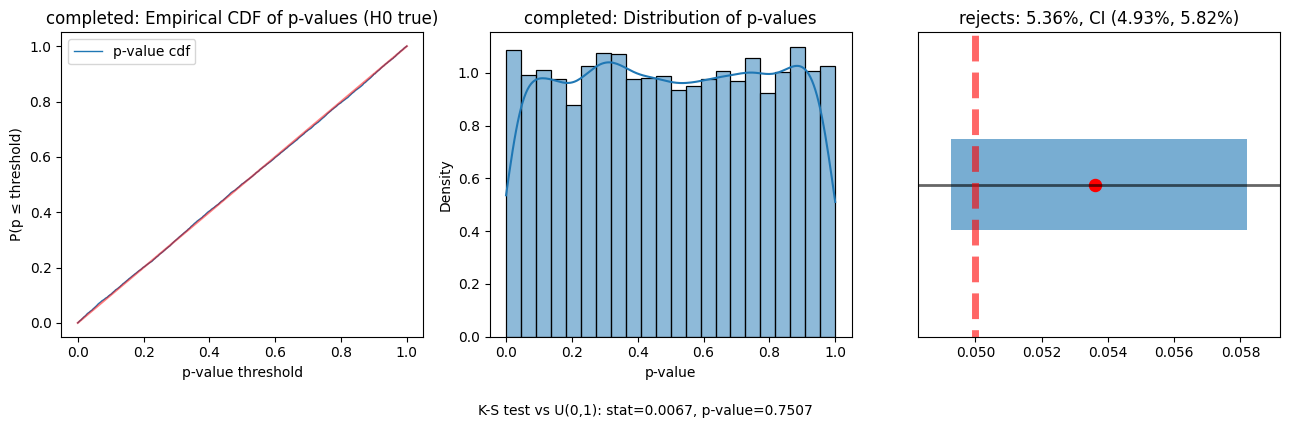

In [ ]:
h0_pvalues = run_aa_simulations(
    generator=generator,
    population=population,
    metric="completed",
    n_simulations=10_000,
    experiment_days=30,
    seed=123,
)

plot_1sterr(
    h0_pvalues,
    alpha=0.05,
    metric="completed",
)

In [ ]:
alpha = 0.05

print(f"Simulations: {len(h0_pvalues):,}")
print(f"Expected rejects: {alpha * len(h0_pvalues):.0f}")
print(f"Actual rejects: {(h0_pvalues < alpha).sum()}")
print(f"Type I error: {(h0_pvalues < alpha).mean():.4%}")

Simulations: 10,000
Expected rejects: 500
Actual rejects: 536
Type I error: 5.3600%


# AB

In [ ]:
import numpy as np
import pandas as pd

from scipy import stats
from tqdm.auto import tqdm


def binomial_ci(successes, n, confidence=0.95):
    """Clopper-Pearson CI для биномиальной вероятности."""
    alpha = 1 - confidence

    low = 0.0 if successes == 0 else stats.beta.ppf(
        alpha / 2,
        successes,
        n - successes + 1,
    )

    high = 1.0 if successes == n else stats.beta.ppf(
        1 - alpha / 2,
        successes + 1,
        n - successes,
    )

    return low, high


def simulate_power_curve(
    generator,
    population,
    metric="completed",
    metric_type="total",
    numerator=None,
    denominator=None,
    ratio_method="linearization",
    effects=np.arange(0, 0.201, 0.05),
    n_simulations=100,
    experiment_days=14,
    alpha=0.05,
    seed=42,
    series_label=None,
):
    """
    Оценивает мощность теста на сетке uplift.

    Для каждого effect:
    1. Берётся случайный непрерывный экспериментальный период.
    2. Treatment назначается заново.
    3. На treatment накладывается uplift (на numerator, если
       metric_type="ratio" — сам ratio не является полем данных,
       которое можно "накрутить" напрямую).
    4. Считается p-value (см. compute_pvalue): Welch t-test на
       total-метрике, либо один из двух вариантов ratio-теста.
    5. power = доля p-value < alpha.

    metric_type="total" (по умолчанию): тестируется `metric`
    на уровне слота, как раньше.

    metric_type="ratio": тестируется numerator/denominator (по
    умолчанию "completed"/"requests", т.е. completions/requests).
    Uplift накладывается на numerator. ratio_method переключает
    способ теста:
        "linearization" — через линеаризацию (Welch t-test на L_i);
        "delta"         — через прямой расчёт Var(ratio) в каждой
                           руке (см. delta_method_ratio_pvalue).
    """
    rng = np.random.default_rng(seed)
    rows = []

    if metric_type == "ratio":
        num_col = numerator or "completed"
        den_col = denominator or "requests"
        uplift_metric = num_col

        if series_label is None:
            method_label = {
                "linearization": "linearization",
                "delta": "delta method",
            }.get(ratio_method, ratio_method)
            series_label = (
                f"{num_col}/{den_col} (ratio, {method_label}), "
                f"{experiment_days} days"
            )
    elif metric_type == "total":
        uplift_metric = metric

        if series_label is None:
            series_label = f"{metric} (total), {experiment_days} days"
    else:
        raise ValueError(
            f"Неизвестный metric_type={metric_type!r}. "
            "Используйте 'total' или 'ratio'."
        )

    for effect in tqdm(effects, desc="Effects"):
        pvalues = np.empty(n_simulations)

        for i in range(n_simulations):
            sample_seed = int(rng.integers(0, np.iinfo(np.int32).max))
            uplift_seed = int(rng.integers(0, np.iinfo(np.int32).max))

            sample = generator.sample_experiment(
                population,
                n_days=experiment_days,
                contiguous=True,
                reassign_treatment=True,
                seed=sample_seed,
            )

            if effect != 0:
                sample = generator.apply_uplift(
                    sample,
                    metric=uplift_metric,
                    uplift=effect,
                    relative=True,
                    stochastic=True,
                    coherent=True,
                    seed=uplift_seed,
                )

            pvalues[i] = compute_pvalue(
                sample,
                metric_type=metric_type,
                metric=metric,
                numerator=numerator,
                denominator=denominator,
                ratio_method=ratio_method,
            )

        rejects = (pvalues < alpha).sum()
        power = rejects / n_simulations
        ci_low, ci_hi = binomial_ci(rejects, n_simulations)

        rows.append({
            "effect": effect,
            "power": power,
            "ci_low": ci_low,
            "ci_hi": ci_hi,
            "series": series_label,
        })

    return pd.DataFrame(rows)

def plot_power_vs_effect(
    df,
    figsize=(10, 6),
    title=None,
):
    """
    Строит график зависимости мощности теста от размера эффекта.
    """
    required_columns = {"effect", "power", "series"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise KeyError(f"В df отсутствуют обязательные колонки: {sorted(missing_columns)}")

    if df.empty:
        raise ValueError("Передан пустой DataFrame. Невозможно построить график.")

    has_ci = "ci_low" in df.columns and "ci_hi" in df.columns

    # Делаем копию, чтобы не менять исходный df снаружи функции
    df = df.copy()

    # Приводим числовые колонки к нормальному numeric-типу.
    # Это защищает matplotlib.fill_between от object, Decimal, строк, pd.NA и т.п.
    numeric_columns = ["effect", "power"]
    if has_ci:
        numeric_columns += ["ci_low", "ci_hi"]

    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Убираем строки, где нельзя построить основную линию
    df = df.dropna(subset=["effect", "power"])

    if df.empty:
        raise ValueError(
            "После приведения effect/power к числам не осталось данных для графика."
        )

    plt.figure(figsize=figsize)

    palette = plt.rcParams["axes.prop_cycle"].by_key().get(
        "color",
        ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"],
    )

    for i, (series_name, part) in enumerate(df.groupby("series", sort=False)):
        d = part.sort_values("effect").copy()
        color = palette[i % len(palette)]

        plt.plot(
            d["effect"].to_numpy(dtype=float),
            d["power"].to_numpy(dtype=float),
            label=str(series_name),
            lw=2,
            color=color,
        )

        if has_ci:
            d_ci = d.dropna(subset=["effect", "ci_low", "ci_hi"])

            if not d_ci.empty:
                plt.fill_between(
                    d_ci["effect"].to_numpy(dtype=float),
                    d_ci["ci_low"].to_numpy(dtype=float),
                    d_ci["ci_hi"].to_numpy(dtype=float),
                    alpha=0.25,
                    color=color,
                    linewidth=0,
                )

    plt.axhline(y=0.8, linestyle="--", linewidth=1.5, label="80% power")
    plt.xlabel("Размер эффекта")
    plt.ylabel("Мощность теста (1 - β)")

    if title is not None:
        plt.title(title)

    plt.grid(True, alpha=0.4)
    plt.ylim(0, 1.05)
    plt.legend(title="Серии", frameon=True)
    plt.tight_layout()
    plt.show()

In [ ]:
# metric="completed"          # metric_type="total"
# metric="requests"           # metric_type="total"
# metric="gmv"                # metric_type="total"
# metric="avg_wait_time_matched"  # metric_type="total"
# metric="load_available"     # metric_type="total"
# metric="avg_available_drivers"  # metric_type="total"
#
# Ratio-метрики (через дельта-метод, metric_type="ratio"):
# numerator="completed", denominator="requests"   # completions/requests (по умолчанию)
# numerator="matched", denominator="requests"     # match_rate, но с корректной дисперсией
# numerator="completed", denominator="matched"    # completion rate | matched

# Для разных компаний акценты отличаются

# * Uber — много внимания уделяет trip completion, ETA, driver utilization, marketplace balance.
# * DoorDash — fill rate (match rate), delivery time, dasher utilization.
# * Airbnb — bookings, booking conversion.
# * Upwork / Fiverr — successful matches и GMV.

power_df = simulate_power_curve(
    generator=generator,
    population=population,
    metric="completed",
    effects=np.arange(0, 0.041, 0.005),
    n_simulations=200,
    experiment_days=30,
    alpha=0.05,
    seed=123,
)

#power_df

Effects:   0%|          | 0/9 [00:00<?, ?it/s]

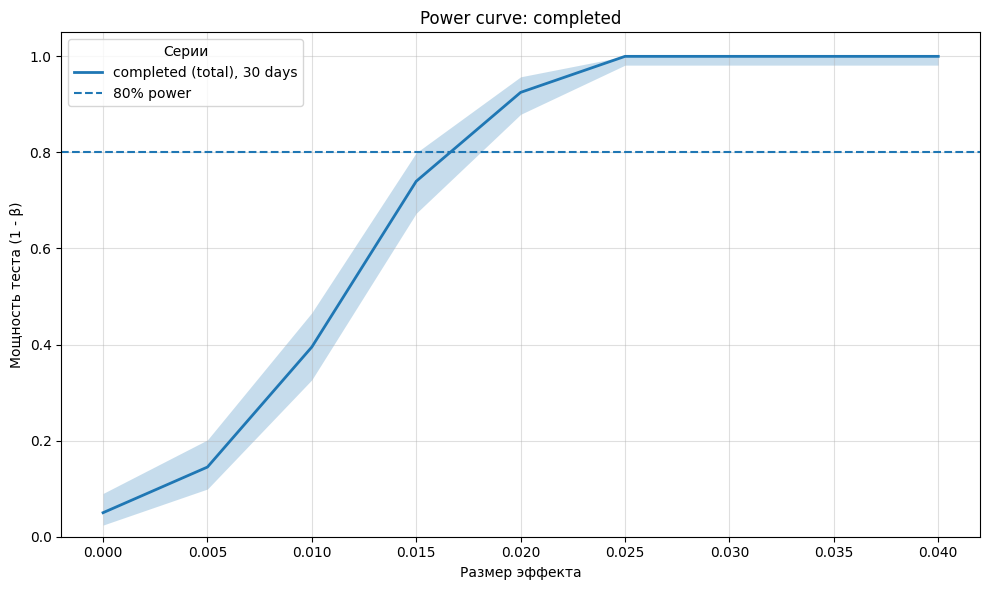

In [ ]:
plot_power_vs_effect(
    power_df,
    title="Power curve: completed",
)

$$\text{completed}
=
\beta_0
+
\beta_1 \cdot treatment
+
\beta_2 \cdot treat\_lag1
+\varepsilon$$

Если генератор не содержит carryover, то ожидаем

* \beta_1 — около нуля в A/A (или положительный после uplift),
* \beta_2 — около нуля и статистически незначим.

In [ ]:
import statsmodels.formula.api as smf


sample = generator.sample_experiment(
    population,
    n_days=30,
    contiguous=True,
    reassign_treatment=True,
    seed=42,
)

# для A/B можно раскомментировать
# sample = generator.apply_uplift(
#     sample,
#     metric="completed",
#     uplift=0.10,
#     seed=123,
# )

df = sample.dropna(subset=["completed", "treat_lag1"]).copy()
df["hour"] = df["interval_start"].dt.hour

model = smf.ols(
    # "completed ~ treatment + treat_lag1",
    # "completed ~ treatment + treat_lag1 + C(region_id)",
    "completed ~ treatment + treat_lag1 + C(region_id) + C(hour)",
    data=df,
).fit(cov_type="nonrobust")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              completed   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     626.4
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:09:27   Log-Likelihood:                -60539.
No. Observations:               14390   AIC:                         1.211e+05
Df Residuals:                   14355   BIC:                         1.214e+05
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              63.7711    

Durbin-Watson меньше 2, значит остатки всё ещё автокоррелированы (что неудивительно — мы специально заложили AR(1)). Поэтому для реального анализа switchback я бы использовал хотя бы cluster-robust стандартные ошибки по регионам:

model = smf.ols(
    "match_rate ~ treatment + treat_lag1",
    data=df,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["region_id"]},
)

# Ratio-метрика: completions / requests — линеаризация vs дельта-метод

Ниже — тот же A/A и power-анализ, что и выше, но для ratio-метрики
`completed / requests` вместо total-метрики `completed`, и сразу
двумя способами.

**Мотивация.** В каждом слоте разное число `requests`, поэтому
ratio-метрика `completed_i / requests_i` на уровне отдельного слота
гетероскедастична: слот с 5 requests и слот со 150 requests вносят в
среднюю ratio совершенно разный шум. Наивный t-test на "средних ratio
по слоту" эту гетероскедастичность игнорирует. Правильный способ —
дельта-метод (Taylor expansion 1-го порядка для $R = \bar X / \bar Y$),
и есть два эквивалентных асимптотически, но по-разному реализуемых
способа его применить.

**1) Линеаризация** (`ratio_method="linearization"`).
Выбираем точку линеаризации $r_0$ (здесь — pooled ratio по всей
выборке эксперимента, обе руки вместе) и переходим к per-unit
псевдо-метрике:

$$L_i = completed_i - r_0 \cdot requests_i$$

Дальше — обычный **Welch t-test** на $L_i$ между treatment и control.
Плюс подхода: он превращает тест ratio-метрики в тест разности
средних, то есть переиспользует всю ту же инфраструктуру, что и для
total-метрик.

**2) Чистый дельта-метод** (`ratio_method="delta"`).
Никакой линеаризации на уровне юнитов нет. В каждой руке $g$
эксперимента напрямую считаем ratio и его дисперсию по дельта-методу:

$$R_g = \frac{\overline{completed}_g}{\overline{requests}_g}, \qquad
Var(R_g) \approx \frac{1}{n_g \cdot \overline{requests}_g^{\,2}}
\Big[
Var(completed_g) - 2 R_g \, Cov(completed_g, requests_g) + R_g^2 \, Var(requests_g)
\Big]$$

и сравниваем руки Wald-статистикой с числом степеней свободы по
Уэлчу-Саттерсвейту:

$$t = \frac{R_t - R_c}{\sqrt{Var(R_t) + Var(R_c)}}$$

**Чем они отличаются на практике.** Асимптотически (много requests на
слот) обе оценки $Var(ratio)$ совпадают. На конечных выборках и при
заметном uplift возможны небольшие расхождения — из-за выбора $r_0$:
"delta" всегда считает $R_g$ и $Var(R_g)$ по своей руке (то есть под
alternative, а не под H0), а "linearization" здесь использует ОДИН
pooled $r_0$ на обе руки (корректная точка линеаризации именно под
H0). Поэтому в A/A обе версии должны давать корректный Type I error,
а на power curve при больших эффектах кривые могут слегка разойтись —
это ожидаемо и стоит проверять эмпирически, а не считать один из
методов заведомо лучше другого.

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

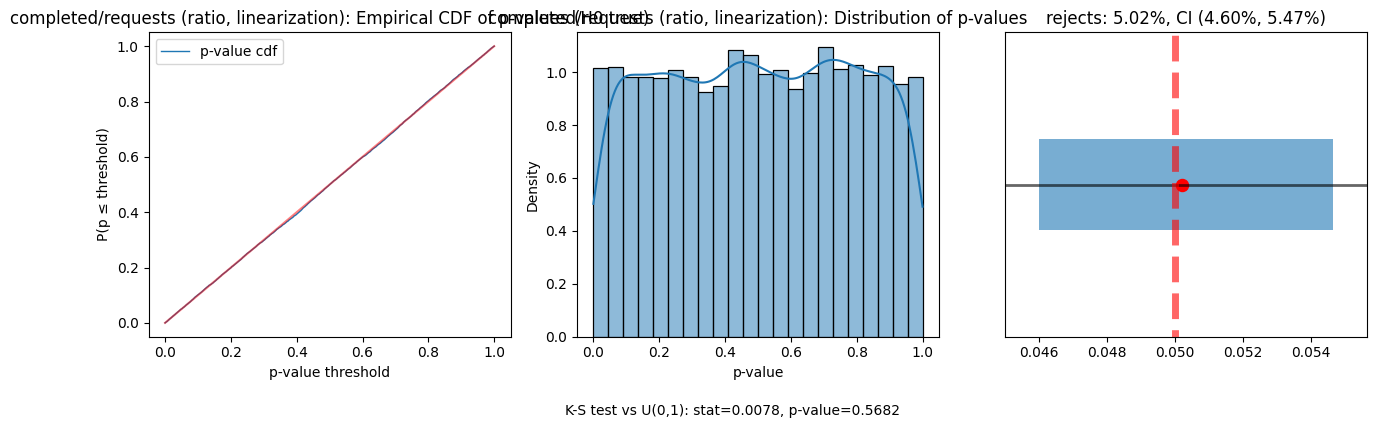

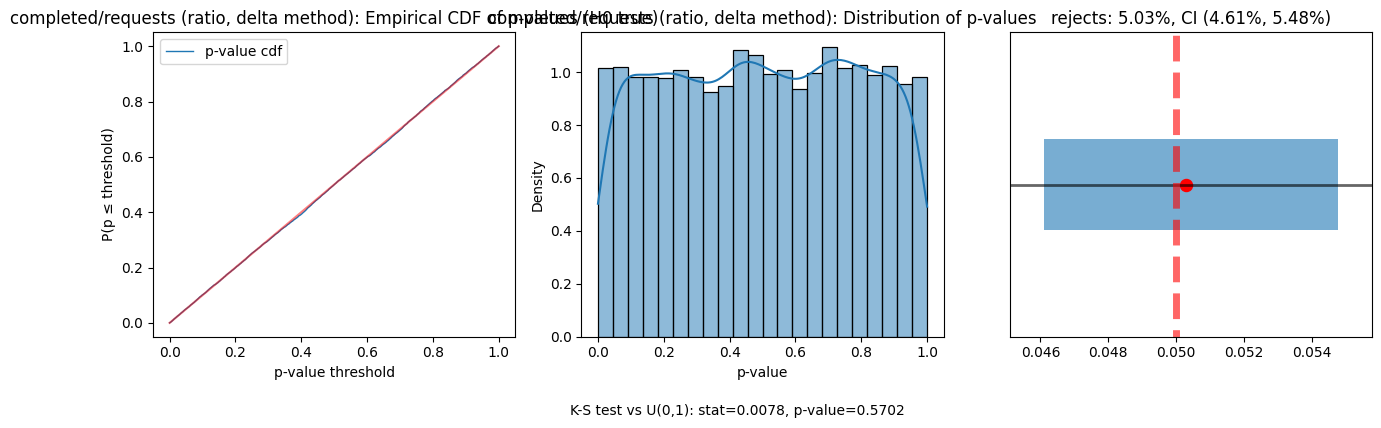

--- ratio_method=linearization ---
Simulations: 10,000
Expected rejects: 500
Actual rejects: 502
Type I error: 5.0200%
--- ratio_method=delta ---
Simulations: 10,000
Expected rejects: 500
Actual rejects: 503
Type I error: 5.0300%


In [ ]:
h0_pvalues_ratio_lin = run_aa_simulations(
    generator=generator,
    population=population,
    metric_type="ratio",
    numerator="completed",
    denominator="requests",
    ratio_method="linearization",
    n_simulations=10_000,
    experiment_days=30,
    seed=123,
)

h0_pvalues_ratio_delta = run_aa_simulations(
    generator=generator,
    population=population,
    metric_type="ratio",
    numerator="completed",
    denominator="requests",
    ratio_method="delta",
    n_simulations=10_000,
    experiment_days=30,
    seed=123,
)

plot_1sterr(
    h0_pvalues_ratio_lin,
    alpha=0.05,
    metric="completed/requests (ratio, linearization)",
)

plot_1sterr(
    h0_pvalues_ratio_delta,
    alpha=0.05,
    metric="completed/requests (ratio, delta method)",
)

alpha = 0.05
for name, pv in [
    ("linearization", h0_pvalues_ratio_lin),
    ("delta", h0_pvalues_ratio_delta),
]:
    print(f"--- ratio_method={name} ---")
    print(f"Simulations: {len(pv):,}")
    print(f"Expected rejects: {alpha * len(pv):.0f}")
    print(f"Actual rejects: {(pv < alpha).sum()}")
    print(f"Type I error: {(pv < alpha).mean():.4%}")

Effects:   0%|          | 0/9 [00:00<?, ?it/s]

Effects:   0%|          | 0/9 [00:00<?, ?it/s]

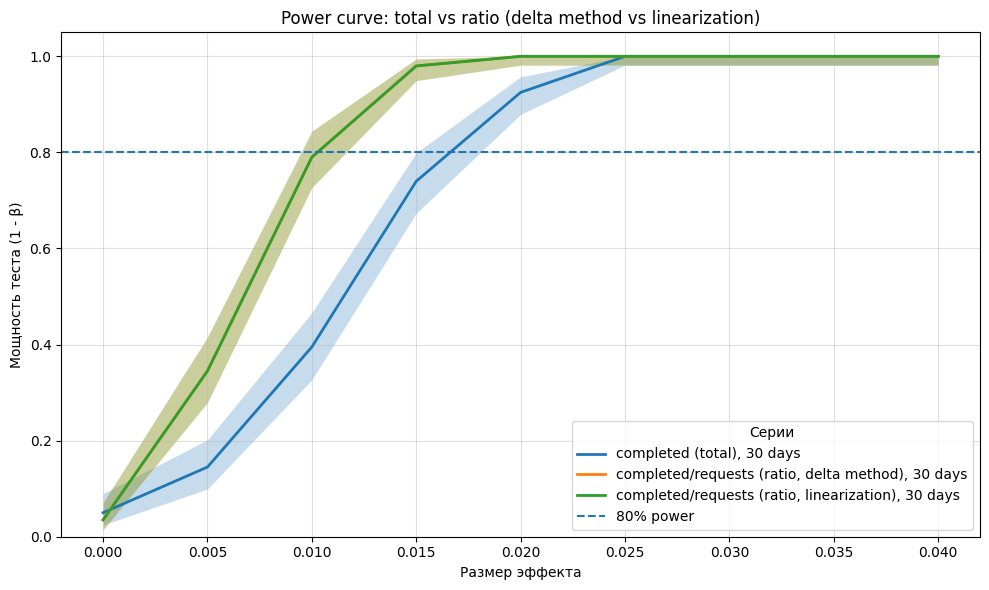

In [ ]:
power_df_ratio_lin = simulate_power_curve(
    generator=generator,
    population=population,
    metric_type="ratio",
    numerator="completed",
    denominator="requests",
    ratio_method="linearization",
    effects=np.arange(0, 0.041, 0.005),
    n_simulations=200,
    experiment_days=30,
    alpha=0.05,
    seed=123,
)

power_df_ratio_delta = simulate_power_curve(
    generator=generator,
    population=population,
    metric_type="ratio",
    numerator="completed",
    denominator="requests",
    ratio_method="delta",
    effects=np.arange(0, 0.041, 0.005),
    n_simulations=200,
    experiment_days=30,
    alpha=0.05,
    seed=123,
)

# Три кривые мощности на одном графике:
#   1) total-метрика completed
#   2) completed/requests через дельта-метод
#   3) completed/requests через линеаризацию
plot_power_vs_effect(
    pd.concat(
        [power_df, power_df_ratio_delta, power_df_ratio_lin],
        ignore_index=True,
    ),
    title="Power curve: total vs ratio (delta method vs linearization)",
)